# Dieterici–VDW, $\Lambda=300$ MeV

This notebook runs the complete asymmetric workflow for **Dieterici–VDW** only. The target incompressibilities are

$$K_0=200,250,\ldots,750\ \mathrm{MeV}.$$

The inclusive range contains **12** values and **24 beta-equilibrium configurations** across two asymmetric branches. Both branches fit $J=32.5$ MeV; `target_l` also fits $L=58.9$ MeV, while `equal_b` imposes $b_{pn}=b_n$. All other numerical and physical parameters are retained from the original notebook: high-resolution beta curves, fixed-$y$ critical points for $y=0.1,\ldots,0.5$, extension to $15n_0$, BPS-crust matching, TOV sequences, numerical audits, tables, and six publication figures.

Run the cells in order. Outputs and checkpoints use model-specific `step50` paths. Marker face color identifies $K_0$, solid/dashed lines identify the asymmetric branch, and VDW curves have black lines. Dieterici–CS/TVM registrations are made in memory.


In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import asdict, replace
from copy import deepcopy
import csv, json, os, sys, tempfile, traceback

os.environ.setdefault('MPLBACKEND', 'Agg')
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'qmm_mpl_cache'))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

candidate_roots = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p.resolve() for p in candidate_roots
             if (p / 'src/qmm').is_dir() and (p / 'src/TOVsolver').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Could not locate the QMM repository root. Start Jupyter inside the cloned repository.')
TOV_TOOLS = ROOT / 'src/TOVsolver'
for path in (ROOT / 'src', TOV_TOOLS):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from qmm.config import load_run_config
from qmm.runner import run_workflow
from qmm.models import MODELS, get_model
import qmm.fixed_y_quantum as fixed_y_module
from qmm.asymmetry import AsymmetricFitResult
from qmm.constants import DEFAULT_PHYSICAL_CONSTANTS, DEFAULT_QUANTUM_SETTINGS
from qmm.fixed_y_quantum import compute_fixed_y_critical_point, fixed_y_quantum_settings
from qmm.ground_state import GroundStateResult
from qmm.quantum import QuantumPressureEvaluator, solve_quantum_critical_point
import clausius_asymmetric_tov as tov_pipeline
from compute_clausius_tvm_lambda300_fixed_y import solve_dieterici_robust
from TOV_solver_code import radius_at_mass, solve_sequence, stitch_crust

print('QMM root:', ROOT)
print('Bundled TOV tools:', TOV_TOOLS)

QMM root: /home/dajuarez4/QMM
Bundled TOV tools: /home/dajuarez4/QMM/src/TOVsolver


## 1. Controls and model registration

The force switches are deliberately off. Turn on only the stage that genuinely needs recomputation. `STRICT_COMPLETE_GRID=True` makes a failed model point stop the notebook; the default records failures and continues so one pathological high-$K_0$ point does not discard completed work.
Results are saved after each completed $K_0$/branch beta run, extended EoS, and TOV sequence, and after each fixed-$y$ critical point. TOV summaries and critical tables use atomic checkpoints. Rerunning skips completed TOV sequences; `FORCE_TOV=True` recomputes them. `RUN_TOV=False` leaves saved TOV results intact. An interrupted calculation within a single configuration must restart that configuration.


In [2]:
K0_VALUES = list(range(200, 751, 50))
assert len(K0_VALUES) == 12 and K0_VALUES[-1] == 750
BRANCHES = ['target_l', 'equal_b']
Y_VALUES = [0.1, 0.2, 0.3, 0.4, 0.5]
LAMBDA_MEV = 300.0
WORKERS = 4

RUN_BETA = True
RUN_CRITICAL = True
RUN_TOV = True
RUN_PLOTS = True
FORCE_BETA = False
FORCE_CRITICAL = False
FORCE_EXTENDED_EOS = False
STRICT_COMPLETE_GRID = False

MAX_DENSITY_RATIO = 15.0
EXTENSION_POINTS = 31
TOV_POINTS = 260 #
FQ_SCAN_POINTS = 141#141
INTEGRAL_POINTS = 400#400

PAPER = ROOT / 'Paper/dieterici_vdw_Lambda300_K0_200_750_step50'
FIGURES = PAPER / 'figures'
TABLES = PAPER / 'tables'
CONFIGS = ROOT / 'examples/generated'
for directory in (FIGURES, TABLES, CONFIGS):
    directory.mkdir(parents=True, exist_ok=True)

# Dieterici-CS/TVM use the Dieterici attraction and the selected repulsive map.
dieterici = get_model('dieterici')
for new_name, repulsive_name in [('dieterici_cs', 'clausius_cs'), ('dieterici_tvm', 'clausius_tvm')]:
    repulsive = get_model(repulsive_name)
    MODELS[new_name] = replace(
        dieterici, name=new_name,
        nid_from_n=repulsive.nid_from_n, n_from_nid=repulsive.n_from_nid,
        volume_fraction=repulsive.volume_fraction,
        species_volume_fraction=repulsive.species_volume_fraction,
        pressure_prefactor=repulsive.pressure_prefactor,
    )
fixed_y_module.FIXED_Y_MODELS = fixed_y_module.FIXED_Y_MODELS | {'dieterici_cs', 'dieterici_tvm'}

MODEL_SPECS = {
    'dieterici_vdw': dict(label='Dieterici–VDW', model_name='dieterici', mean_field='dieterici', ev='vdw', marker='D', bounds=(1.61, 2.01), template='guided_dieterici_vdw_beta_lambda300_highres_k0_300_target_l.json'),
}
for key, spec in MODEL_SPECS.items():
    spec['suite'] = f'guided_{key}_lambda300_k0_200_750_step50'
    spec['source_root'] = ROOT / 'results/generated' / spec['suite']
    spec['tov_dir'] = ROOT / 'results/generated' / f'{spec["suite"]}_tov'

N_CONFIGS = len(MODEL_SPECS) * len(K0_VALUES) * len(BRANCHES)
print(f'{len(K0_VALUES)} K0 values: {K0_VALUES[0]}..{K0_VALUES[-1]} MeV in 50-MeV steps')
print(f'{N_CONFIGS} beta configurations; {N_CONFIGS * len(Y_VALUES)} fixed-y rows requested')
def write_json(path, payload):
    """Replace a checkpoint atomically so interruption preserves the previous file."""
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + '.tmp')
    temporary.write_text(json.dumps(payload, indent=2) + '\n', encoding='utf-8')
    temporary.replace(path)

def write_csv_checkpoint(frame, path):
    temporary = path.with_name(path.name + '.tmp')
    frame.to_csv(temporary, index=False)
    temporary.replace(path)

# Set True to recompute completed mass-radius sequences.
FORCE_TOV = False


12 K0 values: 200..750 MeV in 50-MeV steps
24 beta configurations; 120 fixed-y rows requested


## 2. Build and run the beta-equilibrium grid

Configurations are generated from the previously validated high-resolution files, then only the model, target, branch, output paths, and expanded parameter-search bounds are changed. Each successful run writes its own summary and CSV immediately.

In [3]:
def beta_paths(spec, k0, branch):
    stem = f"{spec['suite']}_k0_{k0}_{branch}"
    directory = spec['source_root'] / f'K0_{k0}_{branch}'
    return directory / f'{stem}_summary.json', directory / f'{stem}_asymmetric_beta.csv'

def config_path(spec, k0, branch):
    return CONFIGS / f"{spec['suite']}_k0_{k0}_{branch}.json"

def build_exact_config(spec, k0, branch):
    source = CONFIGS / spec['template']
    if not source.exists():
        raise FileNotFoundError(source)
    config = json.loads(source.read_text(encoding='utf-8'))
    stem = f"{spec['suite']}_k0_{k0}_{branch}"
    config['run_name'] = stem
    config['model']['name'] = spec['model_name']
    config['model']['parameter_value'] = None
    config['model']['parameter_search'].update({
        'enabled': True, 'target_k0': float(k0),
        'parameter_min': spec['bounds'][0], 'parameter_max': spec['bounds'][1],
        'scan_steps': 241, 'tol': 1.0e-8,
    })
    config['asymmetric'].update({
        'branch_mode': branch, 'target_k0': float(k0), 'target_j': 32.5,
        'target_l': 58.9, 'beta_equilibrium': True,
        'proton_fraction_values': [], 'delta_scan_steps': 401,
        'derivative_step_l': 1.0e-4,
    })
    config['hadronic_eos'].update({
        'n_min_ratio': 0.2, 'n_max_ratio': 5.0, 'n_points': 160,
        'smoothing_window': 9, 'smoothing_degree': 3, 'derivative_floor': 1.0e-10,
    })
    config['quarkyonic'].update({
        'n_min_ratio': 0.05, 'n_max_ratio': 5.0, 'n_points': 120,
        'fq_scan_points': FQ_SCAN_POINTS, 'shell_integral_points': INTEGRAL_POINTS,
        'quark_integral_points': INTEGRAL_POINTS, 'smoothing_window': 9,
        'smoothing_degree': 3, 'derivative_floor': 1.0e-10,
        'lambda_momentum_mev': LAMBDA_MEV,
    })
    output_dir = spec['source_root'] / f'K0_{k0}_{branch}'
    config['output'].update({
        'directory': str(output_dir), 'write_json': True, 'write_csv': True,
        'write_plots': False, 'plot_formats': [],
    })
    return config

all_jobs, pending = [], []
for key, spec in MODEL_SPECS.items():
    for k0 in K0_VALUES:
        for branch in BRANCHES:
            path = config_path(spec, k0, branch)
            path.write_text(json.dumps(build_exact_config(spec, k0, branch), indent=2) + '\n', encoding='utf-8')
            all_jobs.append((key, k0, branch, path))
            summary_path, beta_path = beta_paths(spec, k0, branch)
            if FORCE_BETA or not (summary_path.exists() and beta_path.exists()):
                pending.append((key, k0, branch, path))

print(f'Generated {len(all_jobs)} exact configs; {len(pending)} require beta execution.')

def run_beta_job(job):
    key, k0, branch, path = job
    summary = run_workflow(load_run_config(path))
    fit = summary['asymmetric_fit']
    return key, k0, branch, fit['parameter_value'], fit['K0'], fit['L']

beta_failures = []
if RUN_BETA and pending:
    with ThreadPoolExecutor(max_workers=WORKERS) as pool:
        futures = {pool.submit(run_beta_job, job): job for job in pending}
        for future in as_completed(futures):
            job = futures[future]
            try:
                key, k0, branch, parameter, fitted_k0, fitted_l = future.result()
                print(f'OK {key} K0={k0} {branch}: p={parameter:.8g}, K0={fitted_k0:.5f}, L={fitted_l:.5f}', flush=True)
            except Exception as exc:
                key, k0, branch, path = job
                beta_failures.append({'stage':'beta', 'model_key':key, 'K0_MeV':k0, 'branch_mode':branch, 'error':repr(exc), 'config':str(path)})
                write_json(TABLES / 'beta_failures.json', beta_failures)
                print(f'FAILED {key} K0={k0} {branch}: {exc}', flush=True)
elif pending:
    print('RUN_BETA=False; missing beta products will be excluded downstream.')

(TABLES / 'beta_failures.json').write_text(json.dumps(beta_failures, indent=2) + '\n', encoding='utf-8')
available_beta = []
for key, k0, branch, path in all_jobs:
    summary_path, beta_path = beta_paths(MODEL_SPECS[key], k0, branch)
    if summary_path.exists() and beta_path.exists():
        available_beta.append((key, k0, branch))
missing_beta = N_CONFIGS - len(available_beta)
print(f'Available beta grid: {len(available_beta)}/{N_CONFIGS}; missing={missing_beta}')
if STRICT_COMPLETE_GRID and missing_beta:
    raise RuntimeError(f'Beta grid incomplete: {missing_beta} configurations missing.')

Generated 24 exact configs; 24 require beta execution.
OK dieterici_vdw K0=250 target_l: p=1.6667633, K0=250.00000, L=58.90000
OK dieterici_vdw K0=200 target_l: p=1.6182389, K0=200.00000, L=58.90000
OK dieterici_vdw K0=250 equal_b: p=1.6667633, K0=250.00000, L=81.90019
OK dieterici_vdw K0=200 equal_b: p=1.6182389, K0=200.00000, L=76.03470
OK dieterici_vdw K0=300 target_l: p=1.7103655, K0=300.00000, L=58.90000
OK dieterici_vdw K0=300 equal_b: p=1.7103655, K0=300.00000, L=87.15900
OK dieterici_vdw K0=350 target_l: p=1.7502144, K0=350.00000, L=58.90000
OK dieterici_vdw K0=350 equal_b: p=1.7502144, K0=350.00000, L=91.95553
OK dieterici_vdw K0=400 target_l: p=1.7870825, K0=400.00000, L=58.90000
OK dieterici_vdw K0=450 target_l: p=1.821511, K0=450.00000, L=58.90000
OK dieterici_vdw K0=400 equal_b: p=1.7870825, K0=400.00000, L=96.38514
OK dieterici_vdw K0=450 equal_b: p=1.821511, K0=450.00000, L=100.51464
OK dieterici_vdw K0=550 target_l: p=1.8845399, K0=550.00000, L=58.90000
OK dieterici_vdw

## 3. Fixed-composition critical points

The asymmetric solver is used for $y=0.1$–$0.4$. The $y=0.5$ symmetric limit is duplicated across branch labels. Dieterici models use the previous high-accuracy low-temperature solver. Results are checkpointed after every completed task.

In [4]:
CRITICAL_CSV = TABLES / 'dieterici_vdw_lambda300_fixed_y_critical_points.csv'

def read_critical_cache():
    if FORCE_CRITICAL or not CRITICAL_CSV.exists():
        return {}
    rows = pd.read_csv(CRITICAL_CSV).to_dict('records')
    return {(r['model_key'], int(r['K0_MeV']), r['branch_mode'], float(r['y'])): r for r in rows}

critical_cache = read_critical_cache()

def solve_critical_task(task):
    key, k0, branch, y = task
    spec = MODEL_SPECS[key]
    summary_path, _ = beta_paths(spec, k0, branch)
    payload = json.loads(summary_path.read_text(encoding='utf-8'))
    fit = AsymmetricFitResult(**payload['asymmetric_fit'])
    if np.isclose(y, 0.5):
        if spec['mean_field'] == 'dieterici':
            solved = solve_dieterici_robust(fit, y)
            method = 'high-accuracy symmetric fixed-y limit'
        else:
            ground = GroundStateResult(**payload['ground_state'])
            solved = solve_quantum_critical_point(
                QuantumPressureEvaluator(ground, settings=DEFAULT_QUANTUM_SETTINGS),
                DEFAULT_QUANTUM_SETTINGS,
            )
            method = 'symmetric quantum critical point'
    else:
        solved = (solve_dieterici_robust(fit, y) if spec['mean_field'] == 'dieterici'
                  else compute_fixed_y_critical_point(fit, y, settings=fixed_y_quantum_settings()))
        method = 'fixed-y asymmetric'
    base = {'model_key':key, 'model':spec['label'], 'excluded_volume':spec['ev'],
            'K0_MeV':k0, 'branch_mode':branch, 'y':y, 'source_method':method}
    if solved is None:
        return {**base, 'status':'failed', 'Tc_MeV':np.nan, 'nc_fm3':np.nan, 'Pc_MeV_fm3':np.nan}
    raw = asdict(solved)
    return {**base, 'status':'ok', 'Tc_MeV':float(raw['Tc']),
            'nc_fm3':float(raw['nc']), 'Pc_MeV_fm3':float(raw['Pc'])}

critical_tasks = [(key, k0, branch, y) for key, k0, branch in available_beta for y in Y_VALUES]
critical_pending = [task for task in critical_tasks if task not in critical_cache]
print(f'Critical tasks: {len(critical_tasks)} total, {len(critical_pending)} pending.')
if RUN_CRITICAL and critical_pending:
    with ThreadPoolExecutor(max_workers=WORKERS) as pool:
        futures = {pool.submit(solve_critical_task, task): task for task in critical_pending}
        for future in as_completed(futures):
            task = futures[future]
            try:
                row = future.result()
            except Exception as exc:
                key, k0, branch, y = task
                row = {'model_key':key, 'model':MODEL_SPECS[key]['label'],
                       'excluded_volume':MODEL_SPECS[key]['ev'], 'K0_MeV':k0,
                       'branch_mode':branch, 'y':y, 'status':'failed',
                       'Tc_MeV':np.nan, 'nc_fm3':np.nan, 'Pc_MeV_fm3':np.nan,
                       'source_method':'exception', 'error':repr(exc)}
            critical_cache[task] = row
            write_csv_checkpoint(pd.DataFrame(critical_cache.values()).sort_values(
                ['model_key','branch_mode','y','K0_MeV']), CRITICAL_CSV)
            print(row['status'].upper(), task, flush=True)
elif critical_pending:
    print('RUN_CRITICAL=False; missing critical points will remain absent.')

critical_df = pd.DataFrame(critical_cache.values())
if not critical_df.empty:
    critical_df = critical_df.sort_values(['model_key','branch_mode','y','K0_MeV']).reset_index(drop=True)
display(critical_df.groupby(['model','status']).size().rename('rows').reset_index() if not critical_df.empty else critical_df)

Critical tasks: 120 total, 120 pending.
OK ('dieterici_vdw', 200, 'target_l', 0.2)
OK ('dieterici_vdw', 200, 'target_l', 0.4)
OK ('dieterici_vdw', 200, 'target_l', 0.3)
OK ('dieterici_vdw', 200, 'target_l', 0.1)
OK ('dieterici_vdw', 200, 'target_l', 0.5)
OK ('dieterici_vdw', 200, 'equal_b', 0.1)
OK ('dieterici_vdw', 200, 'equal_b', 0.2)
OK ('dieterici_vdw', 200, 'equal_b', 0.3)
OK ('dieterici_vdw', 250, 'target_l', 0.1)
OK ('dieterici_vdw', 200, 'equal_b', 0.4)
OK ('dieterici_vdw', 250, 'target_l', 0.2)
OK ('dieterici_vdw', 200, 'equal_b', 0.5)
OK ('dieterici_vdw', 250, 'target_l', 0.4)
OK ('dieterici_vdw', 250, 'target_l', 0.3)
OK ('dieterici_vdw', 250, 'equal_b', 0.1)
OK ('dieterici_vdw', 250, 'target_l', 0.5)
OK ('dieterici_vdw', 250, 'equal_b', 0.2)
OK ('dieterici_vdw', 250, 'equal_b', 0.3)
OK ('dieterici_vdw', 250, 'equal_b', 0.4)
OK ('dieterici_vdw', 250, 'equal_b', 0.5)
OK ('dieterici_vdw', 300, 'target_l', 0.1)
OK ('dieterici_vdw', 300, 'target_l', 0.2)
OK ('dieterici_vdw', 300

,model,status,rows
0,Dieterici–VDW,failed,11
1,Dieterici–VDW,ok,109


## 4. Extended EoS, BPS crust, and TOV sequences

Every available beta curve is extended from $5n_0$ toward $15n_0$, stitched to the bundled BPS crust, and sampled at 260 central pressures. The notebook uses the existing tested pipeline functions directly, which allows the expanded grid and the in-memory Dieterici–CS/TVM registrations without changing project source files.

In [5]:
def monotone_physical_eos(rows):
    energy = np.asarray([row['energy_density'] for row in rows], dtype=float)
    pressure = np.asarray([row['pressure'] for row in rows], dtype=float)
    valid = np.isfinite(energy) & np.isfinite(pressure) & (energy > 0) & (pressure > 0)
    energy, pressure = energy[valid], pressure[valid]
    order = np.argsort(energy); energy, pressure = energy[order], pressure[order]
    keep = np.zeros(len(pressure), dtype=bool); last = -np.inf
    for i, value in enumerate(pressure):
        if value > last:
            keep[i] = True; last = value
    return energy[keep], pressure[keep]

tov_failures = []
for key, spec in MODEL_SPECS.items():
    selected = [(k0, branch) for model_key, k0, branch in available_beta if model_key == key]
    if not selected:
        continue
    spec['tov_dir'].mkdir(parents=True, exist_ok=True)
    eos_dir = spec['tov_dir'] / 'extended_eos'; mr_dir = spec['tov_dir'] / 'curves'
    eos_dir.mkdir(parents=True, exist_ok=True); mr_dir.mkdir(parents=True, exist_ok=True)
    tov_pipeline.SOURCE_ROOT = spec['source_root']
    tov_pipeline.SOURCE_SUITE = spec['suite']
    summary_file = spec['tov_dir'] / 'model_tov_summary.json'
    previous = json.loads(summary_file.read_text(encoding='utf-8')) if summary_file.exists() else []
    summary_cache = {(int(row['K0_MeV']), row['branch_mode']): row for row in previous}
    results, tasks = [], []
    for k0, branch in selected:
        mr_file = mr_dir / f'K0_{k0}_{branch}_mass_radius.csv'
        if (k0, branch) in summary_cache and mr_file.exists() and not (FORCE_TOV or FORCE_EXTENDED_EOS or FORCE_BETA):
            print(f'CACHED TOV {key} K0={k0} {branch}', flush=True)
            continue
        if not RUN_TOV:
            continue
        cached = eos_dir / f'K0_{k0}_{branch}_extended_beta_eos.csv'
        if cached.exists() and not FORCE_EXTENDED_EOS:
            try:
                results.append(tov_pipeline.load_cached_model(k0, branch, cached))
            except Exception as exc:
                tov_failures.append({'stage':'load_eos','model_key':key,'K0_MeV':k0,'branch_mode':branch,'error':repr(exc)})
                write_json(TABLES / 'tov_failures.json', tov_failures)
        else:
            tasks.append((k0, branch, MAX_DENSITY_RATIO, EXTENSION_POINTS, LAMBDA_MEV,
                          FQ_SCAN_POINTS, INTEGRAL_POINTS, INTEGRAL_POINTS))
    if RUN_TOV and tasks:
        with ThreadPoolExecutor(max_workers=WORKERS) as pool:
            futures = {pool.submit(tov_pipeline.compute_extended_model, task): task for task in tasks}
            for future in as_completed(futures):
                task = futures[future]; k0, branch = task[:2]
                try:
                    result = future.result(); results.append(result)
                    tov_pipeline.write_extended_eos(eos_dir / f'K0_{k0}_{branch}_extended_beta_eos.csv', result)
                    print(f'EXTENDED {key} K0={k0} {branch}: {len(result["rows"])} rows', flush=True)
                except Exception as exc:
                    tov_failures.append({'stage':'extend_eos','model_key':key,'K0_MeV':k0,'branch_mode':branch,'error':repr(exc)})
                    write_json(TABLES / 'tov_failures.json', tov_failures)
                    print(f'EXTENSION FAILED {key} K0={k0} {branch}: {exc}', flush=True)
    for result in sorted(results, key=lambda item:(item['k0'], item['branch'])):
        k0, branch = result['k0'], result['branch']
        try:
            energy, pressure = monotone_physical_eos(result['rows'])
            if len(energy) < 8:
                raise RuntimeError(f'Only {len(energy)} monotone positive EoS points')
            stitched_e, stitched_p, transition_e, transition_p = stitch_crust(energy, pressure)
            mr_rows = solve_sequence(stitched_e, stitched_p, transition_e, TOV_POINTS, 50.0, 250.0)
            result['mr_rows'] = mr_rows
            tov_pipeline.write_mr(mr_dir / f'K0_{k0}_{branch}_mass_radius.csv', result)
            masses = np.asarray([row['mass_msun'] for row in mr_rows]); peak_i = int(np.argmax(masses))
            peak, last = mr_rows[peak_i], mr_rows[-1]
            summary_cache[(k0, branch)] = {
                'model_key':key, 'model':spec['label'], 'K0_MeV':k0, 'branch_mode':branch,
                'maximum_mass_msun':float(peak['mass_msun']),
                'radius_at_maximum_mass_km':float(peak['radius_km']),
                'central_energy_at_maximum_mass_mev_fm3':float(peak['central_energy_density_mev_fm3']),
                'radius_at_1p4_msun_km':radius_at_mass(mr_rows, 1.4),
                'final_unstable_mass_msun':float(last['mass_msun']),
                'final_unstable_radius_km':float(last['radius_km']),
                'maximum_at_eos_boundary':peak_i == len(mr_rows)-1,
                'maximum_density_ratio_reached':float(max(row['n_over_n0'] for row in result['rows'])),
                'crust_transition_energy_mev_fm3':float(transition_e),
                'crust_transition_pressure_mev_fm3':float(transition_p),
            }
            write_json(summary_file, list(summary_cache.values()))
            print(f'TOV {key} K0={k0} {branch}: Mmax={peak["mass_msun"]:.4f}', flush=True)
        except Exception as exc:
            tov_failures.append({'stage':'tov','model_key':key,'K0_MeV':k0,'branch_mode':branch,'error':repr(exc)})
            write_json(TABLES / 'tov_failures.json', tov_failures)
            print(f'TOV FAILED {key} K0={k0} {branch}: {exc}', flush=True)
    write_json(summary_file, list(summary_cache.values()))

write_json(TABLES / 'tov_failures.json', tov_failures)
print(f'TOV-stage failures recorded: {len(tov_failures)}')
if STRICT_COMPLETE_GRID and tov_failures:
    raise RuntimeError('TOV grid incomplete; inspect tov_failures.json.')

EXTENDED dieterici_vdw K0=200 target_l: 150 rows
EXTENDED dieterici_vdw K0=250 target_l: 150 rows
EXTENDED dieterici_vdw K0=200 equal_b: 150 rows
EXTENDED dieterici_vdw K0=250 equal_b: 150 rows
EXTENDED dieterici_vdw K0=300 target_l: 150 rows
EXTENDED dieterici_vdw K0=350 target_l: 150 rows
EXTENDED dieterici_vdw K0=300 equal_b: 150 rows
EXTENDED dieterici_vdw K0=350 equal_b: 150 rows
EXTENDED dieterici_vdw K0=400 target_l: 150 rows
EXTENDED dieterici_vdw K0=400 equal_b: 150 rows
EXTENDED dieterici_vdw K0=450 equal_b: 150 rows
EXTENDED dieterici_vdw K0=450 target_l: 150 rows
EXTENDED dieterici_vdw K0=500 target_l: 150 rows
EXTENDED dieterici_vdw K0=500 equal_b: 150 rows
EXTENDED dieterici_vdw K0=550 target_l: 150 rows
EXTENDED dieterici_vdw K0=550 equal_b: 150 rows
EXTENDED dieterici_vdw K0=600 target_l: 150 rows
EXTENDED dieterici_vdw K0=600 equal_b: 150 rows
EXTENDED dieterici_vdw K0=650 target_l: 150 rows
EXTENDED dieterici_vdw K0=650 equal_b: 150 rows
EXTENDED dieterici_vdw K0=700 

/home/dajuarez4/QMM/src/TOVsolver/tov.py:277: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  psol = odeint(self.tov_eq, [P, m], r, rtol=rtol)


TOV dieterici_vdw K0=200 equal_b: Mmax=2.5233


/home/dajuarez4/QMM/src/TOVsolver/tov.py:284: RuntimeWarning: divide by zero encountered in divide
  diff = (m_R[1:] - m_R[:-1])/m_R[1:]
/home/dajuarez4/QMM/src/TOVsolver/tov.py:284: RuntimeWarning: overflow encountered in divide
  diff = (m_R[1:] - m_R[:-1])/m_R[1:]
/home/dajuarez4/QMM/src/TOVsolver/tov.py:284: RuntimeWarning: invalid value encountered in divide
  diff = (m_R[1:] - m_R[:-1])/m_R[1:]


TOV dieterici_vdw K0=200 target_l: Mmax=2.5834
TOV dieterici_vdw K0=250 equal_b: Mmax=2.5785
TOV dieterici_vdw K0=250 target_l: Mmax=2.6639
TOV dieterici_vdw K0=300 equal_b: Mmax=2.6152
TOV dieterici_vdw K0=300 target_l: Mmax=2.7137
TOV dieterici_vdw K0=350 equal_b: Mmax=2.6415
TOV dieterici_vdw K0=350 target_l: Mmax=2.7470
TOV dieterici_vdw K0=400 equal_b: Mmax=2.6612
TOV dieterici_vdw K0=400 target_l: Mmax=2.7707
TOV dieterici_vdw K0=450 equal_b: Mmax=2.6767
TOV dieterici_vdw K0=450 target_l: Mmax=2.7881
TOV dieterici_vdw K0=500 equal_b: Mmax=2.6891
TOV dieterici_vdw K0=500 target_l: Mmax=2.8014
TOV dieterici_vdw K0=550 equal_b: Mmax=2.6993
TOV dieterici_vdw K0=550 target_l: Mmax=2.8117
TOV dieterici_vdw K0=600 equal_b: Mmax=2.7078
TOV dieterici_vdw K0=600 target_l: Mmax=2.8198
TOV dieterici_vdw K0=650 equal_b: Mmax=2.7151
TOV dieterici_vdw K0=650 target_l: Mmax=2.8263
TOV dieterici_vdw K0=700 equal_b: Mmax=2.7214
TOV dieterici_vdw K0=700 target_l: Mmax=2.8316
TOV dieterici_vdw K0=75

## 5. Consolidated table and numerical audit

In [6]:
records = []
curve_index = {}
for key, spec in MODEL_SPECS.items():
    summary_path = spec['tov_dir'] / 'model_tov_summary.json'
    tov_rows = json.loads(summary_path.read_text(encoding='utf-8')) if summary_path.exists() else []
    tov_by_key = {(int(r['K0_MeV']), r['branch_mode']):r for r in tov_rows}
    for k0, branch in [(k,b) for mk,k,b in available_beta if mk == key]:
        summary_file, beta_file = beta_paths(spec, k0, branch)
        payload = json.loads(summary_file.read_text(encoding='utf-8'))
        fit = payload['asymmetric_fit']; beta = pd.read_csv(beta_file)
        tov = tov_by_key.get((k0, branch), {})
        eos_path = spec['tov_dir'] / 'extended_eos' / f'K0_{k0}_{branch}_extended_beta_eos.csv'
        mr_path = spec['tov_dir'] / 'curves' / f'K0_{k0}_{branch}_mass_radius.csv'
        eos = pd.read_csv(eos_path) if eos_path.exists() else None
        mr = pd.read_csv(mr_path) if mr_path.exists() else None
        curve_index[(key,k0,branch)] = {'beta':beta, 'eos':eos, 'mr':mr}
        closure = float(np.nanmax(np.abs(beta.n_p + beta.n_n - beta.n_b * (1-beta.quark_fraction))))
        rec = {
            'model_key':key, 'model':spec['label'], 'mean_field':spec['mean_field'],
            'excluded_volume':spec['ev'], 'K0_MeV':k0, 'branch_mode':branch,
            'parameter_name':fit['parameter_name'], 'parameter_value':float(fit['parameter_value']),
            'J_MeV':float(fit['J']), 'L_MeV':float(fit['L']),
            'a_n':float(fit['a_n']), 'a_pn':float(fit['a_pn']),
            'b_n':float(fit['b_n']), 'b_pn':float(fit['b_pn']),
            'maximum_vs2_beta':float(np.nanmax(beta.vs2)),
            'density_closure_error':closure,
            'pressure_monotone_beta':bool(np.all(np.diff(beta.pressure) >= -1e-8)),
            'maximum_mass_msun':tov.get('maximum_mass_msun',np.nan),
            'radius_at_maximum_mass_km':tov.get('radius_at_maximum_mass_km',np.nan),
            'radius_at_1p4_msun_km':tov.get('radius_at_1p4_msun_km',np.nan),
            'maximum_at_eos_boundary':tov.get('maximum_at_eos_boundary',np.nan),
            'maximum_density_ratio_reached':tov.get('maximum_density_ratio_reached',np.nan),
        }
        if spec['mean_field'] == 'clausius':
            rec['clausius_denominator_at_15n0'] = 1 + rec['parameter_value'] * MAX_DENSITY_RATIO * DEFAULT_PHYSICAL_CONSTANTS.n0
        else:
            rec['clausius_denominator_at_15n0'] = np.nan
        records.append(rec)
        write_csv_checkpoint(pd.DataFrame(records), TABLES / 'dieterici_vdw_lambda300_all_parameters_and_results.csv')

results = pd.DataFrame(records).sort_values(['model_key','branch_mode','K0_MeV']).reset_index(drop=True)
RESULTS_CSV = TABLES / 'dieterici_vdw_lambda300_all_parameters_and_results.csv'
results.to_csv(RESULTS_CSV, index=False)
display(results)
print('Saved:', RESULTS_CSV)
print('Beta closure max:', results.density_closure_error.max())
print('Non-monotone beta tables:', int((~results.pressure_monotone_beta).sum()))
print('TOV curves missing:', int(results.maximum_mass_msun.isna().sum()))
print('Models not reaching 15 n0:', int((results.maximum_density_ratio_reached < 14.999).sum()))
singular = results[(results.mean_field == 'clausius') & (results.clausius_denominator_at_15n0 <= 0)]
if len(singular):
    print(f'WARNING: {len(singular)} negative-c Clausius fits cross 1+c*n=0 before 15 n0; their extension is physically/domain limited.')

,model_key,model,mean_field,excluded_volume,K0_MeV,branch_mode,parameter_name,parameter_value,J_MeV,L_MeV,...,b_pn,maximum_vs2_beta,density_closure_error,pressure_monotone_beta,maximum_mass_msun,radius_at_maximum_mass_km,radius_at_1p4_msun_km,maximum_at_eos_boundary,maximum_density_ratio_reached,clausius_denominator_at_15n0
0,dieterici_vdw,Dieterici–VDW,dieterici,vdw,200,equal_b,alpha,1.618239,32.5,76.034704,...,2.023046,0.708329,2.220446e-16,True,2.523310,13.3200,13.491852,False,15.0,NaN
1,dieterici_vdw,Dieterici–VDW,dieterici,vdw,250,equal_b,alpha,1.666763,32.5,81.900189,...,2.276344,0.655873,2.220446e-16,True,2.578545,13.8550,13.860576,False,15.0,NaN
2,dieterici_vdw,Dieterici–VDW,dieterici,vdw,300,equal_b,alpha,1.710365,32.5,87.158998,...,2.477940,0.621281,2.220446e-16,True,2.615220,14.2200,14.112148,False,15.0,NaN
3,dieterici_vdw,Dieterici–VDW,dieterici,vdw,350,equal_b,alpha,1.750214,32.5,91.955529,...,2.644109,0.597239,1.665335e-16,True,2.641469,14.5125,14.296565,False,15.0,NaN
4,dieterici_vdw,Dieterici–VDW,dieterici,vdw,400,equal_b,alpha,1.787082,32.5,96.385142,...,2.784621,0.578726,1.665335e-16,True,2.661211,14.7275,14.435317,False,15.0,NaN
5,dieterici_vdw,Dieterici–VDW,dieterici,vdw,450,equal_b,alpha,1.821511,32.5,100.514645,...,2.905775,0.565586,1.665335e-16,True,2.676654,14.9100,14.545471,False,15.0,NaN
6,dieterici_vdw,Dieterici–VDW,dieterici,vdw,500,equal_b,alpha,1.853897,32.5,104.392960,...,3.011854,0.553589,1.665335e-16,True,2.689070,15.0550,14.634687,False,15.0,NaN
7,dieterici_vdw,Dieterici–VDW,dieterici,vdw,550,equal_b,alpha,1.884540,32.5,108.057161,...,3.105896,0.545162,2.220446e-16,True,2.699290,15.1850,14.707766,False,15.0,NaN
8,dieterici_vdw,Dieterici–VDW,dieterici,vdw,600,equal_b,alpha,1.913675,32.5,111.536124,...,3.190128,0.537742,2.220446e-16,True,2.707846,15.2850,14.766848,False,15.0,NaN
9,dieterici_vdw,Dieterici–VDW,dieterici,vdw,650,equal_b,alpha,1.941489,32.5,114.852847,...,3.266227,0.531938,1.665335e-16,True,2.715125,15.3750,14.819133,False,15.0,NaN


Saved: /home/dajuarez4/QMM/Paper/dieterici_vdw_Lambda300_K0_200_750_step50/tables/dieterici_vdw_lambda300_all_parameters_and_results.csv
Beta closure max: 2.220446049250313e-16
Non-monotone beta tables: 0
TOV curves missing: 0
Models not reaching 15 n0: 0


## 6. Publication plots

All six figures show Dieterici–VDW only. Marker face color identifies $K_0$ and solid/dashed lines identify the branch. VDW uses black connecting lines; CS and TVM use the original color convention.


In [7]:
mpl.rcParams.update({
    'font.family':'serif', 'font.serif':['STIXGeneral','DejaVu Serif'],
    'mathtext.fontset':'stix', 'font.size':8.5, 'axes.labelsize':9.5,
    'axes.linewidth':.8, 'xtick.direction':'in', 'ytick.direction':'in',
    'xtick.top':True, 'ytick.right':True, 'legend.frameon':False,
    'pdf.fonttype':42, 'ps.fonttype':42, 'savefig.bbox':'tight',
})
CMAP = mpl.colormaps['turbo']; NORM = mpl.colors.Normalize(200, 750)
BRANCH_STYLE = {'target_l':'-', 'equal_b':'--'}
BRANCH_LABEL = {'target_l':r'$b_{pn}\ne b_n$', 'equal_b':r'$b_{pn}=b_n$'}

def kcolor(k0): return CMAP(NORM(k0))
def line_color(spec, k0): return 'black' if spec['ev'] == 'vdw' else kcolor(k0)
def curve_style(spec, k0, branch, markevery=14):
    return dict(color=line_color(spec,k0), ls=BRANCH_STYLE[branch], lw=.65,
                marker=spec['marker'], markevery=markevery, ms=2.0,
                mfc=kcolor(k0), mec='black' if spec['ev']=='vdw' else kcolor(k0), mew=.25, alpha=.72)

def add_legends(fig, axis):
    model_handles = [mpl.lines.Line2D([],[], color='black' if s['ev']=='vdw' else '.45', marker=s['marker'],
                    mfc='white', mec='black', lw=.8, label=s['label']) for s in MODEL_SPECS.values()]
    branch_handles = [mpl.lines.Line2D([],[], color='black', ls=BRANCH_STYLE[b], label=BRANCH_LABEL[b]) for b in BRANCHES]
    first = axis.legend(handles=model_handles, fontsize=6.7, ncol=2, loc='best')
    axis.add_artist(first); axis.legend(handles=branch_handles, fontsize=7, loc='lower right')
    sm = mpl.cm.ScalarMappable(norm=NORM, cmap=CMAP); sm.set_array([])
    fig.colorbar(sm, ax=fig.axes, fraction=.018, pad=.015, label=r'$K_0$ [MeV]')

def finish(fig, name):
    for ax in fig.axes:
        if hasattr(ax, 'grid'): ax.grid(color='.92', lw=.4)
    fig.savefig(FIGURES / f'{name}.pdf')
    fig.savefig(FIGURES / f'{name}.svg')
    fig.savefig(FIGURES / f'{name}.png', dpi=260)
    plt.close(fig)

# (1) beta binding and sound speed, one row per branch.
fig, axes = plt.subplots(2,2,figsize=(10.5,7.0))
for row_i, branch in enumerate(BRANCHES):
    for (key,k0,b), curves in curve_index.items():
        if b != branch: continue
        spec=MODEL_SPECS[key]; beta=curves['beta']
        binding=((beta.energy_density-beta.eps_e-beta.eps_mu)/beta.n_b-938.0)/1000
        axes[row_i,0].plot(beta.n_over_n0,binding,**curve_style(spec,k0,branch))
        axes[row_i,1].plot(beta.n_over_n0,beta.vs2,**curve_style(spec,k0,branch))
    axes[row_i,0].set(xlim=(0,5),xlabel=r'$n_B/n_0$',ylabel=r'$\epsilon_{HQ}/n_B-m_N$ [GeV]')
    axes[row_i,1].set(xlim=(0,5),xlabel=r'$n_B/n_0$',ylabel=r'$c_s^2$')
    axes[row_i,1].text(.98,.96,BRANCH_LABEL[branch],transform=axes[row_i,1].transAxes,ha='right',va='top')
add_legends(fig,axes[0,0]); finish(fig,'figure_dieterici_vdw_beta_binding_sound')

# (2) beta composition.
fig, axes = plt.subplots(2,2,figsize=(10.5,7.0))
for row_i, branch in enumerate(BRANCHES):
    for (key,k0,b), curves in curve_index.items():
        if b != branch: continue
        spec=MODEL_SPECS[key]; beta=curves['beta']
        axes[row_i,0].plot(beta.n_over_n0,beta.y,**curve_style(spec,k0,branch))
        axes[row_i,1].plot(beta.n_over_n0,beta.quark_fraction,**curve_style(spec,k0,branch))
    axes[row_i,0].set(xlim=(0,5),ylim=(0,.5),xlabel=r'$n_B/n_0$',ylabel=r'$y$')
    axes[row_i,1].set(xlim=(0,5),ylim=(0,1),xlabel=r'$n_B/n_0$',ylabel=r'$f_q$')
    axes[row_i,1].text(.98,.96,BRANCH_LABEL[branch],transform=axes[row_i,1].transAxes,ha='right',va='top')
add_legends(fig,axes[0,0]); finish(fig,'figure_dieterici_vdw_beta_composition')

# (3) extended EoS and mass-radius curves.
fig, axes = plt.subplots(2,2,figsize=(10.5,7.0))
for row_i, branch in enumerate(BRANCHES):
    for (key,k0,b), curves in curve_index.items():
        if b != branch or curves['eos'] is None or curves['mr'] is None: continue
        spec=MODEL_SPECS[key]; eos=curves['eos']; mr=curves['mr']
        axes[row_i,0].plot(eos.energy_density/1000,eos.pressure/1000,**curve_style(spec,k0,branch))
        axes[row_i,1].plot(mr.radius_km,mr.mass_msun,**curve_style(spec,k0,branch,markevery=25))
    axes[row_i,0].set(xlabel=r'$\epsilon$ [GeV fm$^{-3}$]',ylabel=r'$p$ [GeV fm$^{-3}$]')
    axes[row_i,1].set(xlabel=r'$R$ [km]',ylabel=r'$M$ [$M_\odot$]')
    axes[row_i,1].text(.98,.96,BRANCH_LABEL[branch],transform=axes[row_i,1].transAxes,ha='right',va='top')
add_legends(fig,axes[0,0]); finish(fig,'figure_dieterici_vdw_eos_mass_radius')

# (4) maximum observables.
fig, axes = plt.subplots(1,3,figsize=(12.2,3.9),sharex=True)
fields=[('maximum_mass_msun',r'$M_{\max}$ [$M_\odot$]'),('radius_at_maximum_mass_km',r'$R_{M_{\max}}$ [km]'),('maximum_vs2_beta',r'$\max c_s^2$')]
for ax,(field,ylabel) in zip(axes,fields):
    for key,spec in MODEL_SPECS.items():
        for branch in BRANCHES:
            part=results[(results.model_key==key)&(results.branch_mode==branch)].sort_values('K0_MeV')
            ax.plot(part.K0_MeV,part[field],**curve_style(spec,part.K0_MeV.iloc[0] if len(part) else 200,branch,markevery=1))
            if len(part):
                ax.scatter(part.K0_MeV,part[field],c=part.K0_MeV,cmap=CMAP,norm=NORM,marker=spec['marker'],s=13,
                           edgecolors='black' if spec['ev']=='vdw' else 'none',linewidths=.25,zorder=3)
    ax.set(xlabel=r'$K_0$ [MeV]',ylabel=ylabel)
add_legends(fig,axes[0]); finish(fig,'figure_dieterici_vdw_observables')

# (5) fitted parameters.
fig, axes = plt.subplots(2,2,figsize=(10.2,7.0),sharex=True)
panels=[('parameter_value','model parameter'),('L_MeV',r'$L$ [MeV]'),('a_n',r'$a_n$ [MeV fm$^3$]'),('b_n',r'$b_n$ [fm$^3$]')]
for ax,(field,ylabel) in zip(axes.flat,panels):
    for key,spec in MODEL_SPECS.items():
        for branch in BRANCHES:
            part=results[(results.model_key==key)&(results.branch_mode==branch)].sort_values('K0_MeV')
            if not len(part): continue
            ax.plot(part.K0_MeV,part[field],color='black' if spec['ev']=='vdw' else '.55',ls=BRANCH_STYLE[branch],lw=.7)
            ax.scatter(part.K0_MeV,part[field],c=part.K0_MeV,cmap=CMAP,norm=NORM,marker=spec['marker'],s=12,
                       edgecolors='black' if spec['ev']=='vdw' else 'none',linewidths=.25)
    ax.set(ylabel=ylabel)
for ax in axes[-1]: ax.set_xlabel(r'$K_0$ [MeV]')
add_legends(fig,axes[0,0]); finish(fig,'figure_dieterici_vdw_fitted_parameters')

# (6) fixed-y critical points: five rows for this model.
fig, axes = plt.subplots(len(Y_VALUES),2,figsize=(11.0,15.0),sharex=True)
okcrit = critical_df[critical_df.status=='ok'] if not critical_df.empty else critical_df
for row_i,y in enumerate(Y_VALUES):
    for key,spec in MODEL_SPECS.items():
        for branch in BRANCHES:
            part=okcrit[(okcrit.model_key==key)&(okcrit.branch_mode==branch)&np.isclose(okcrit.y,y)].sort_values('K0_MeV')
            if not len(part): continue
            for ax,field in zip(axes[row_i],['nc_fm3','Tc_MeV']):
                ax.plot(part.K0_MeV,part[field],color='black' if spec['ev']=='vdw' else '.55',ls=BRANCH_STYLE[branch],lw=.65)
                ax.scatter(part.K0_MeV,part[field],c=part.K0_MeV,cmap=CMAP,norm=NORM,marker=spec['marker'],s=11,
                           edgecolors='black' if spec['ev']=='vdw' else 'none',linewidths=.25)
    axes[row_i,0].set_ylabel(rf'$n_c$ [fm$^{{-3}}$], $y={y:.1f}$')
    axes[row_i,1].set_ylabel(rf'$T_c$ [MeV], $y={y:.1f}$')
for ax in axes[-1]: ax.set_xlabel(r'$K_0$ [MeV]')
add_legends(fig,axes[0,0]); finish(fig,'figure_dieterici_vdw_fixed_y_critical')

print('Saved six figures in PDF, SVG, and PNG under', FIGURES)

Saved six figures in PDF, SVG, and PNG under /home/dajuarez4/QMM/Paper/dieterici_vdw_Lambda300_K0_200_750_step50/figures


## 7. Display final figures and completion summary

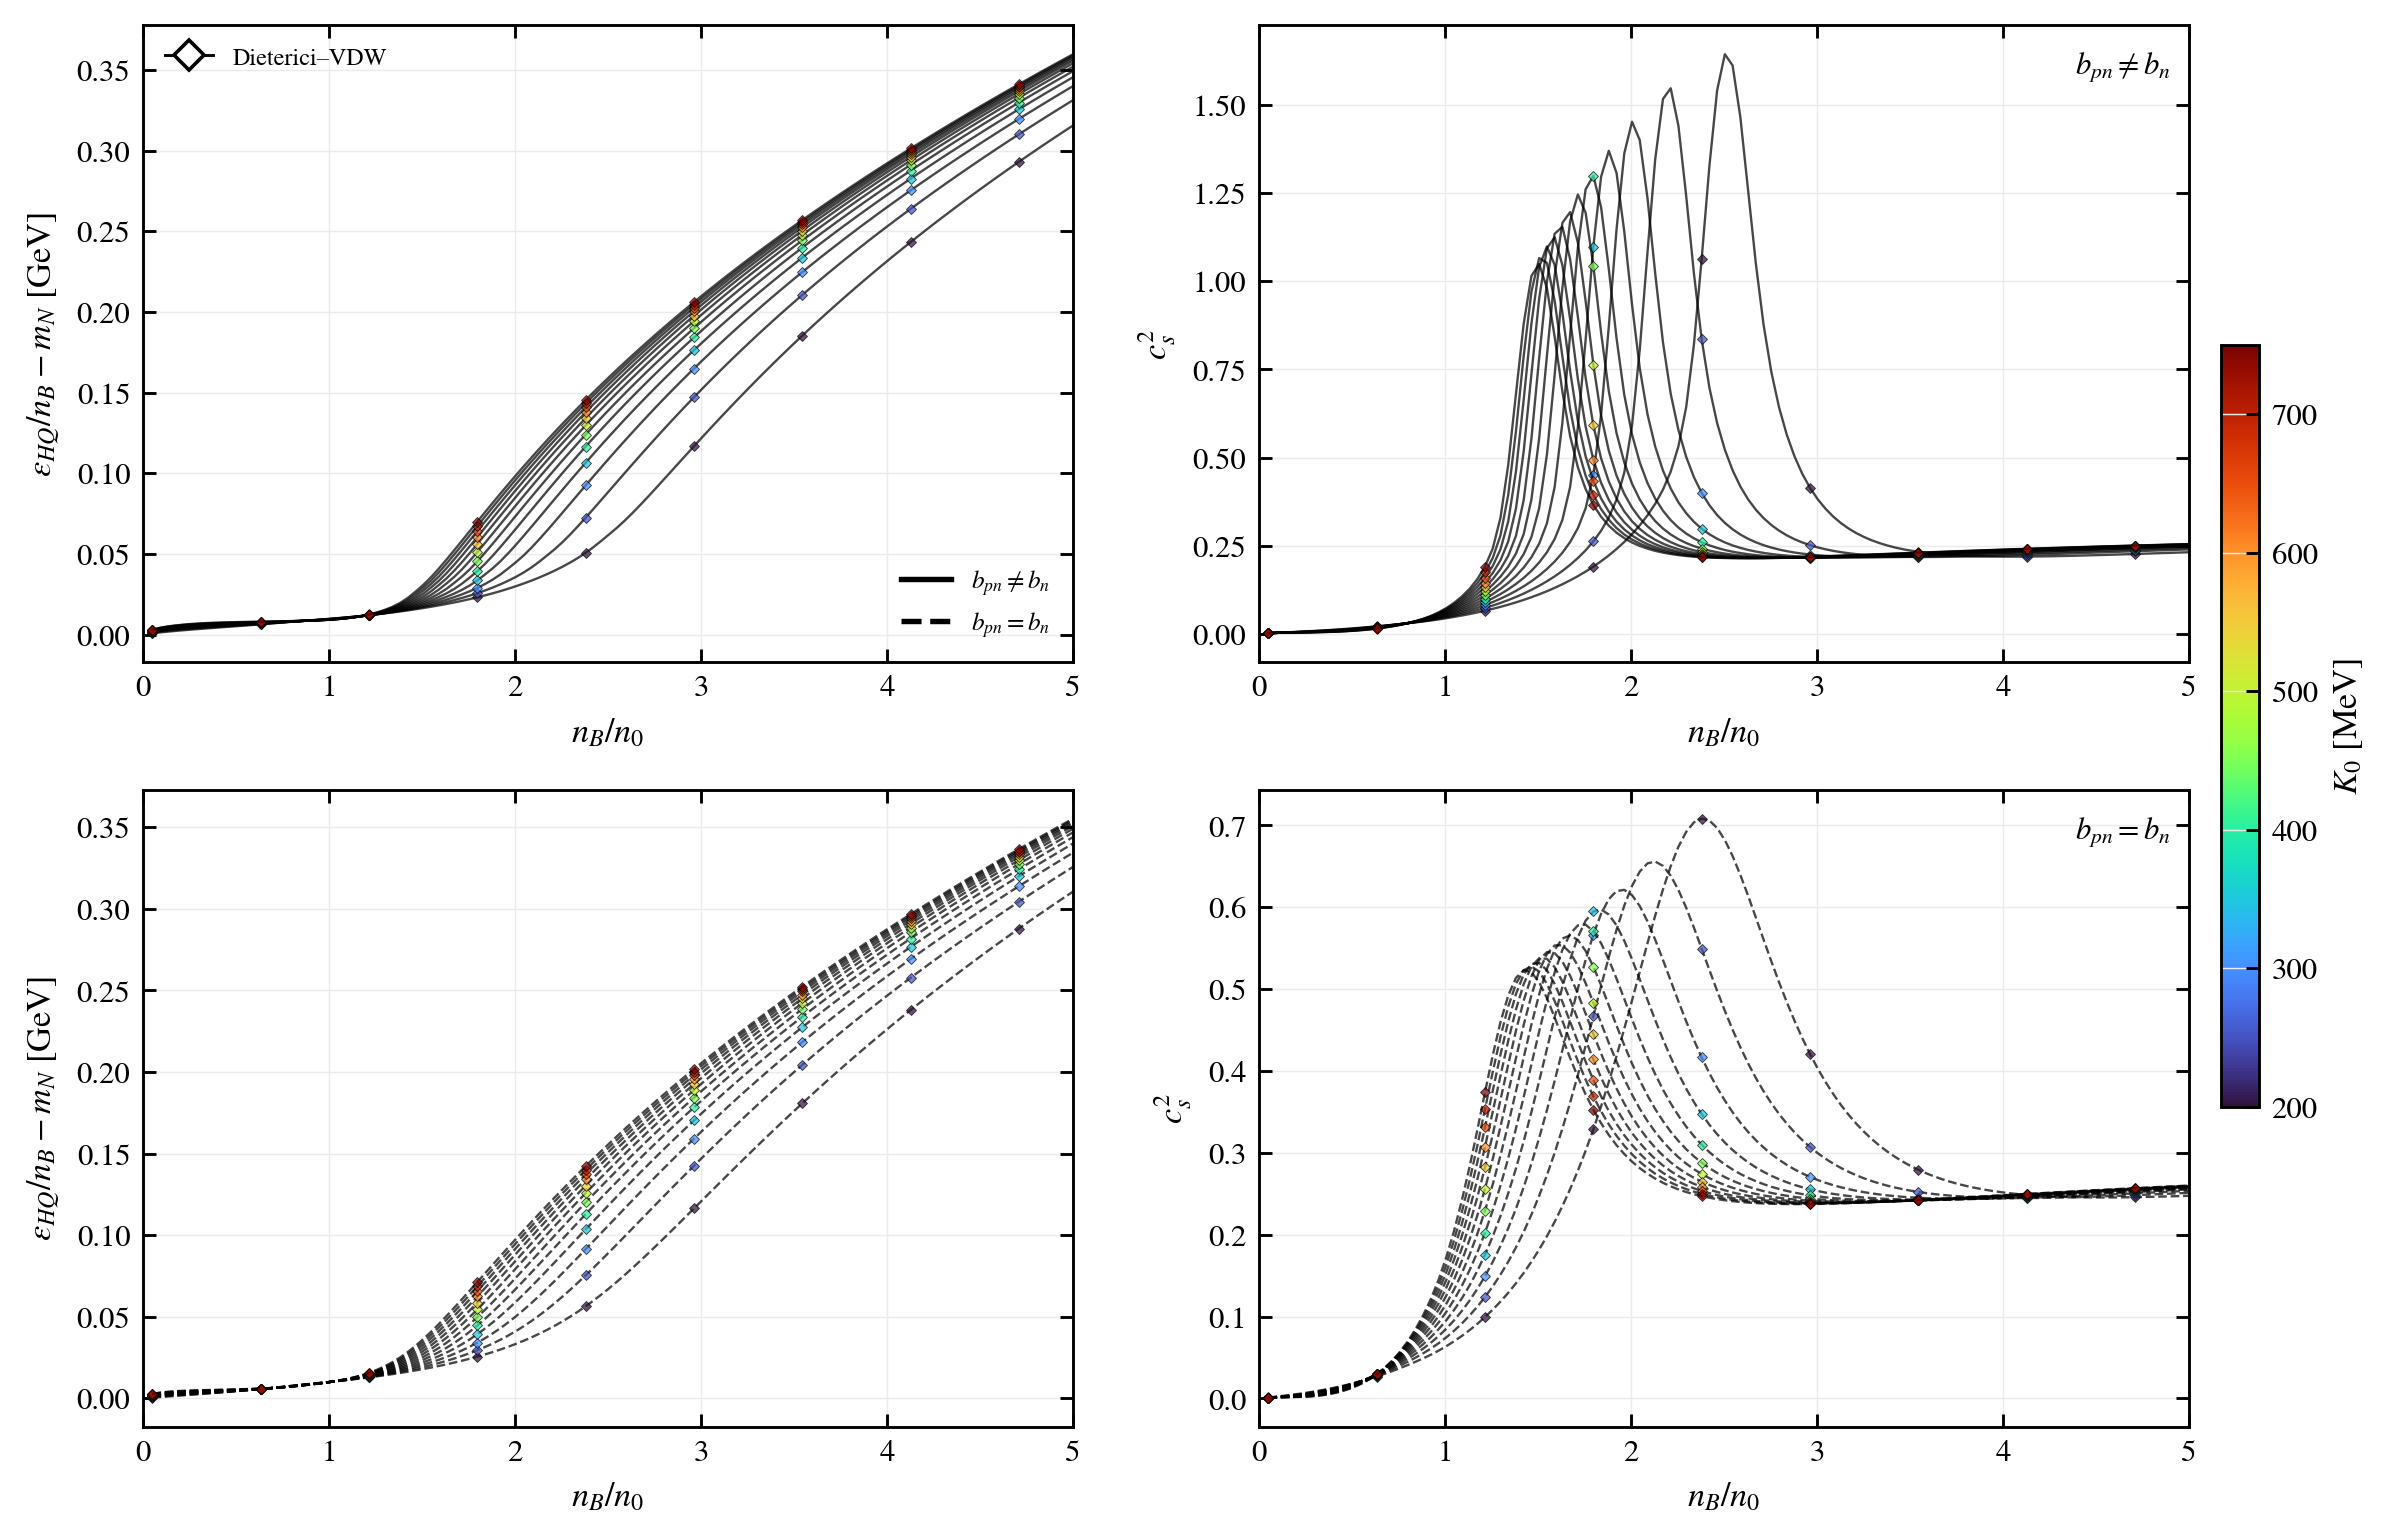

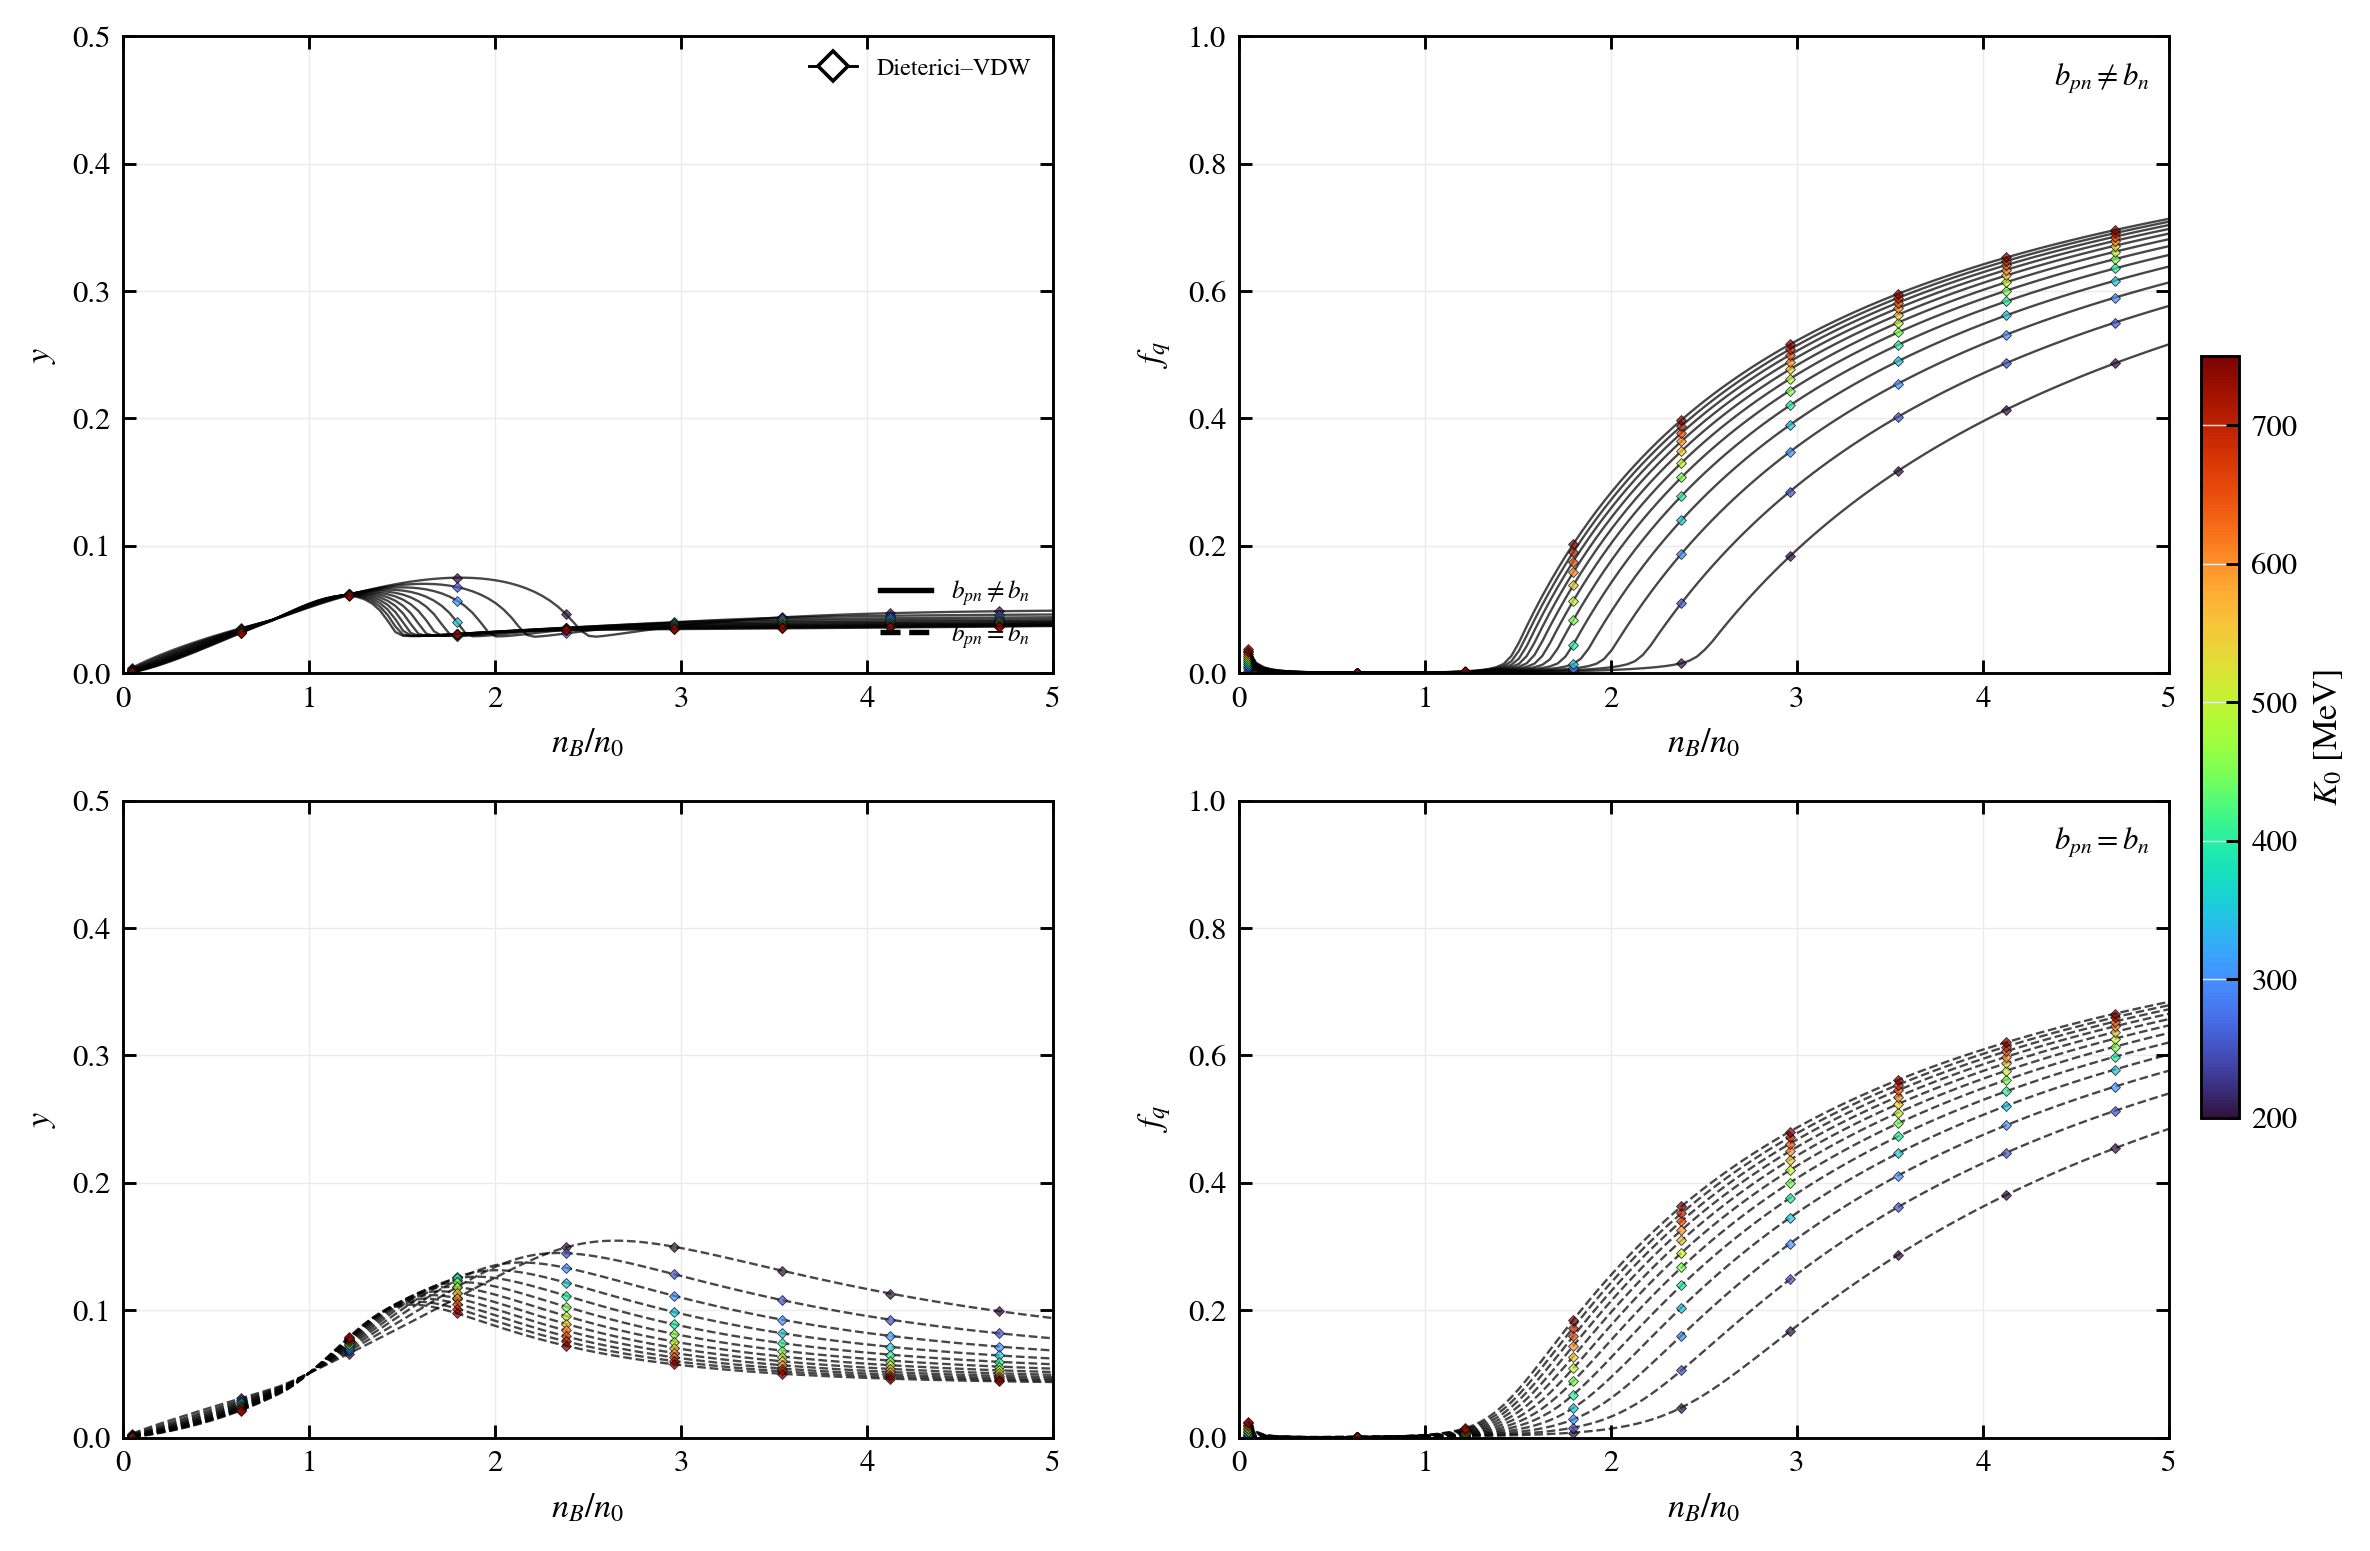

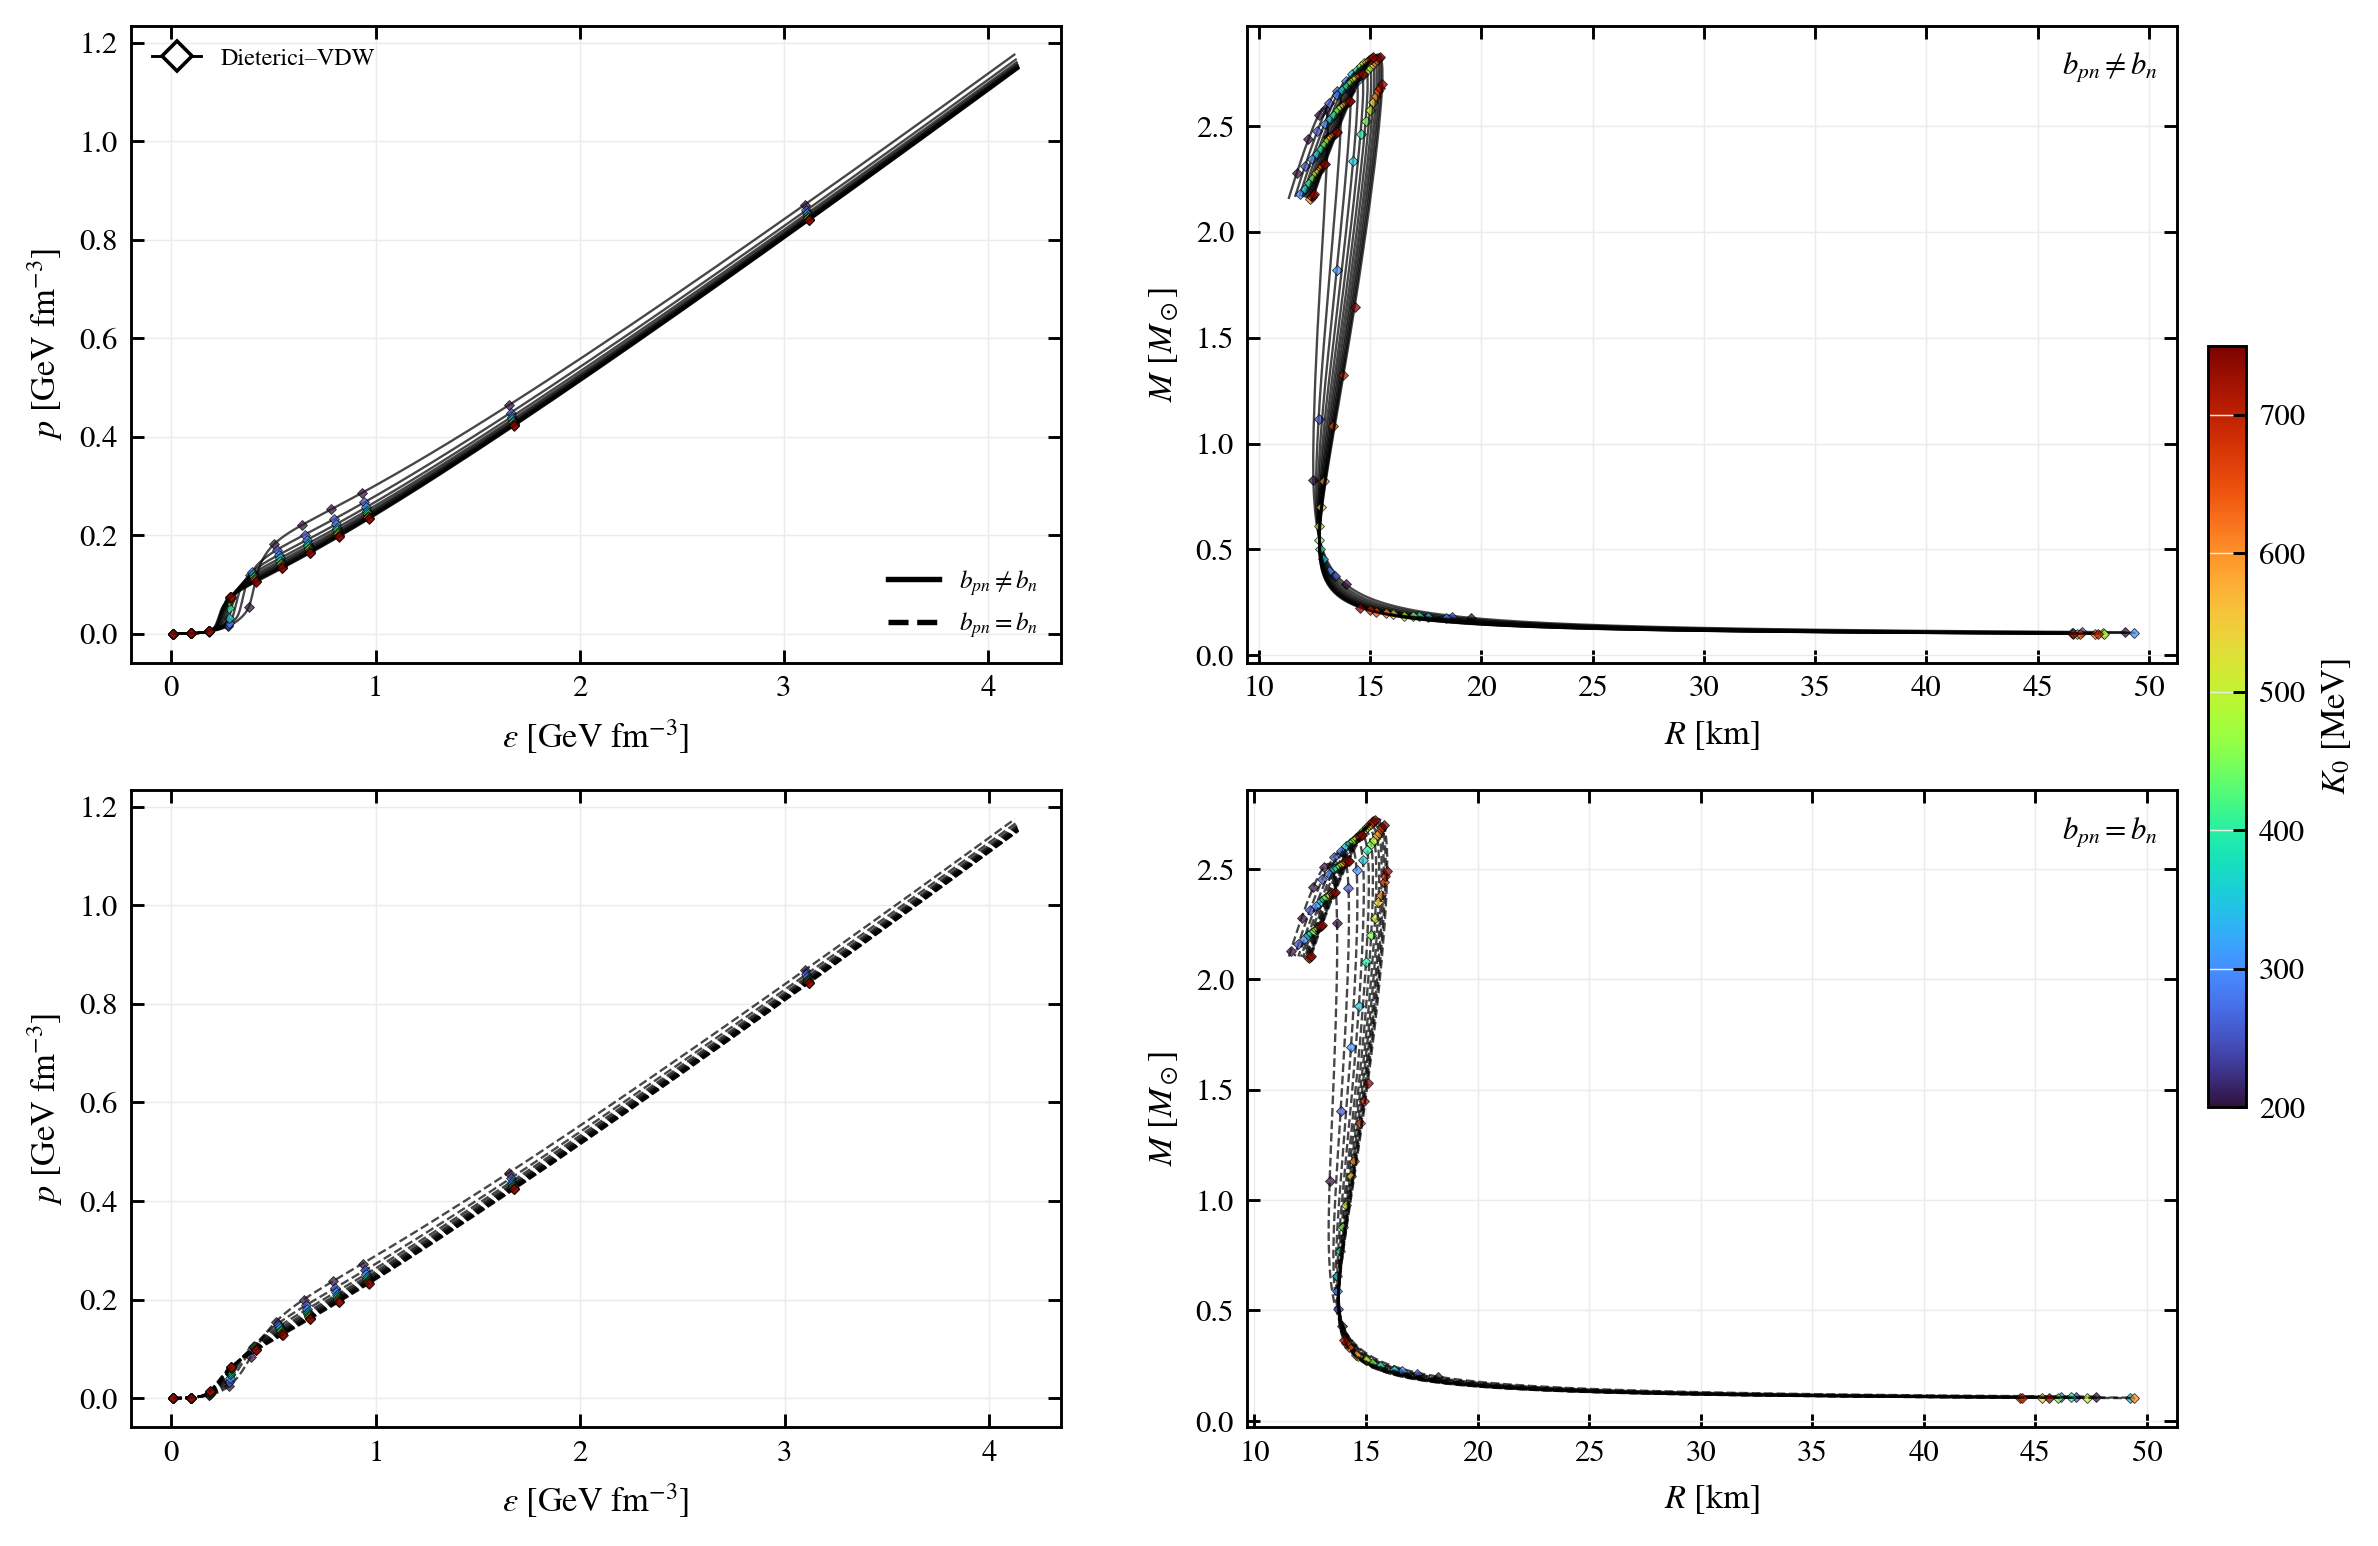

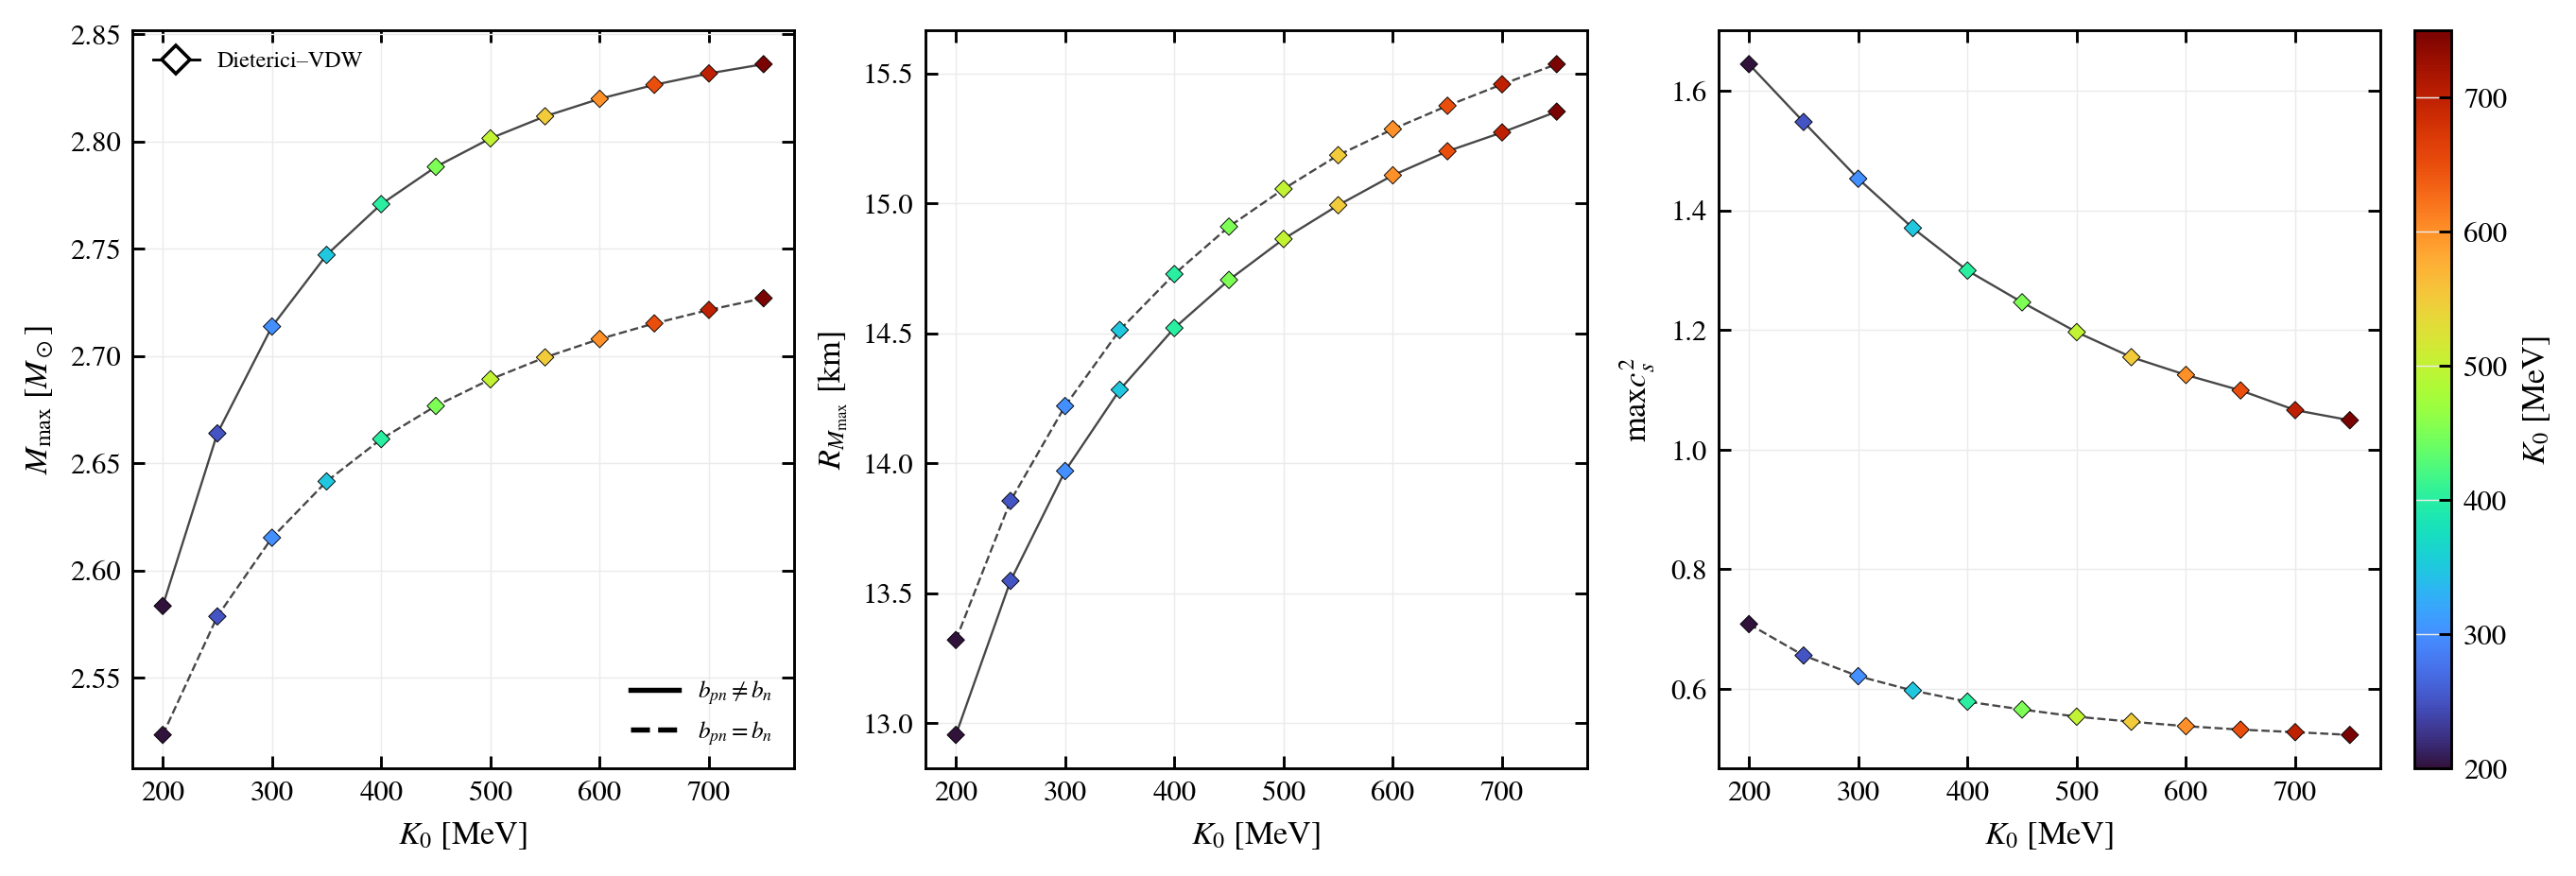

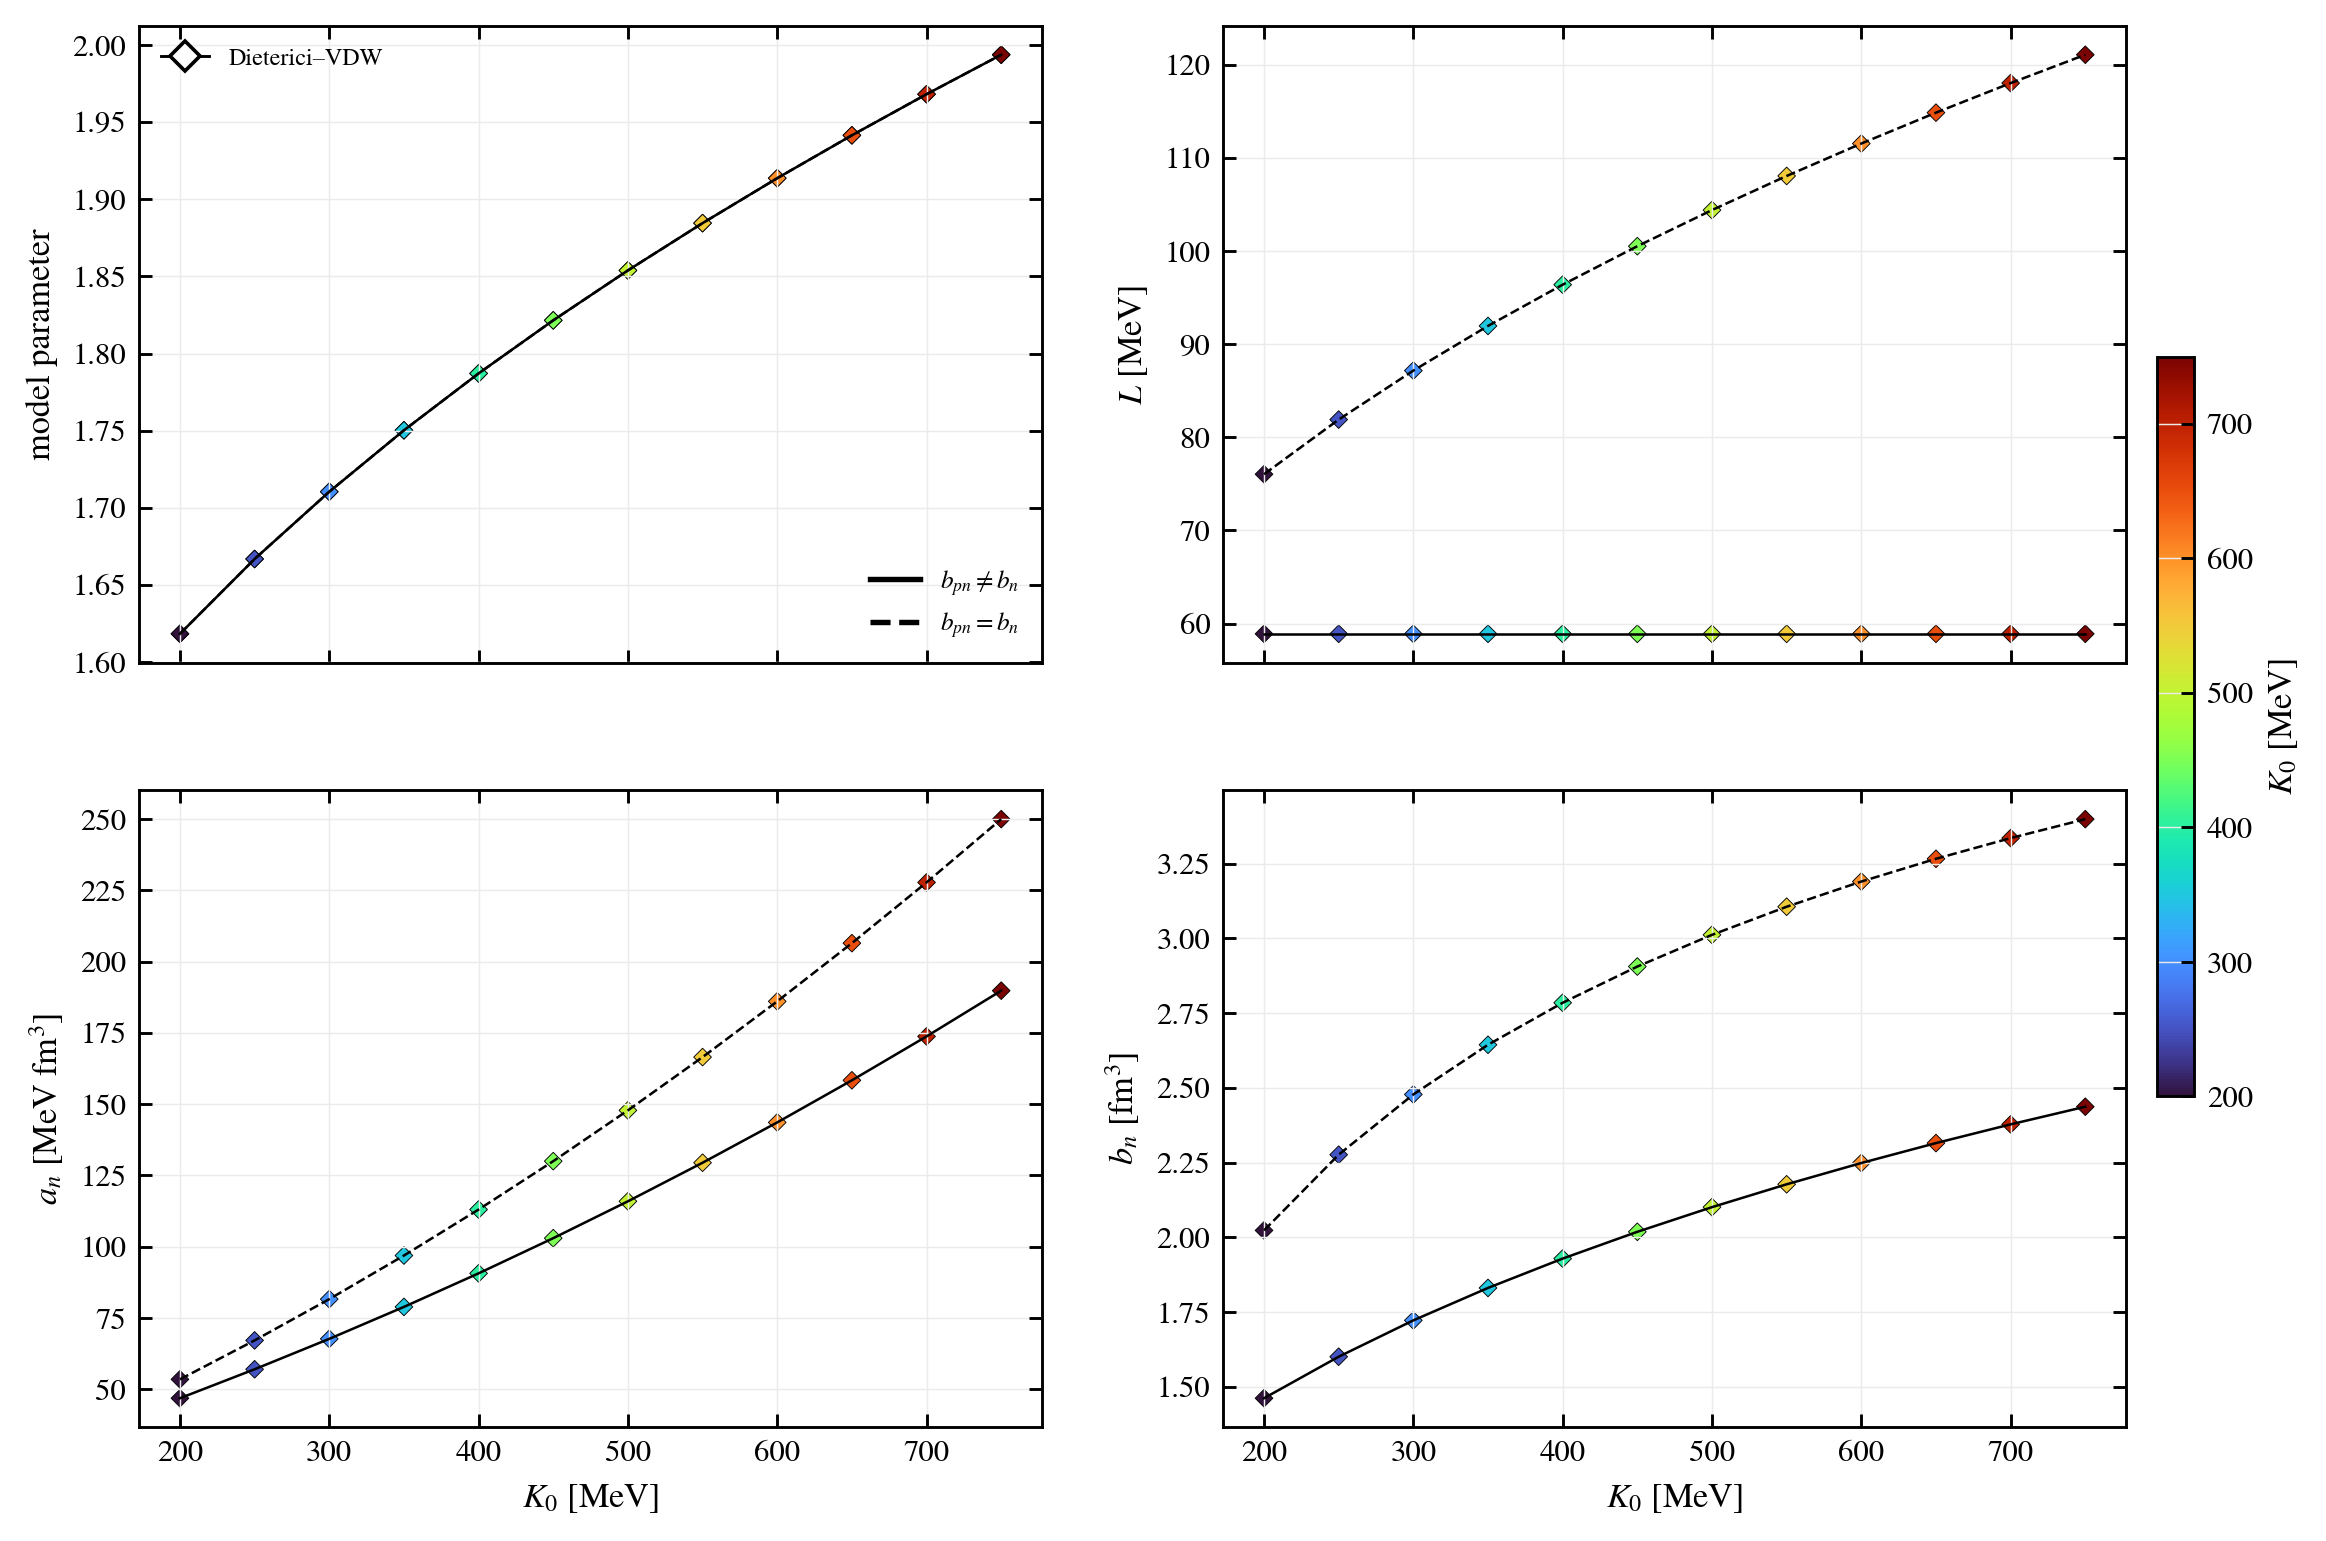

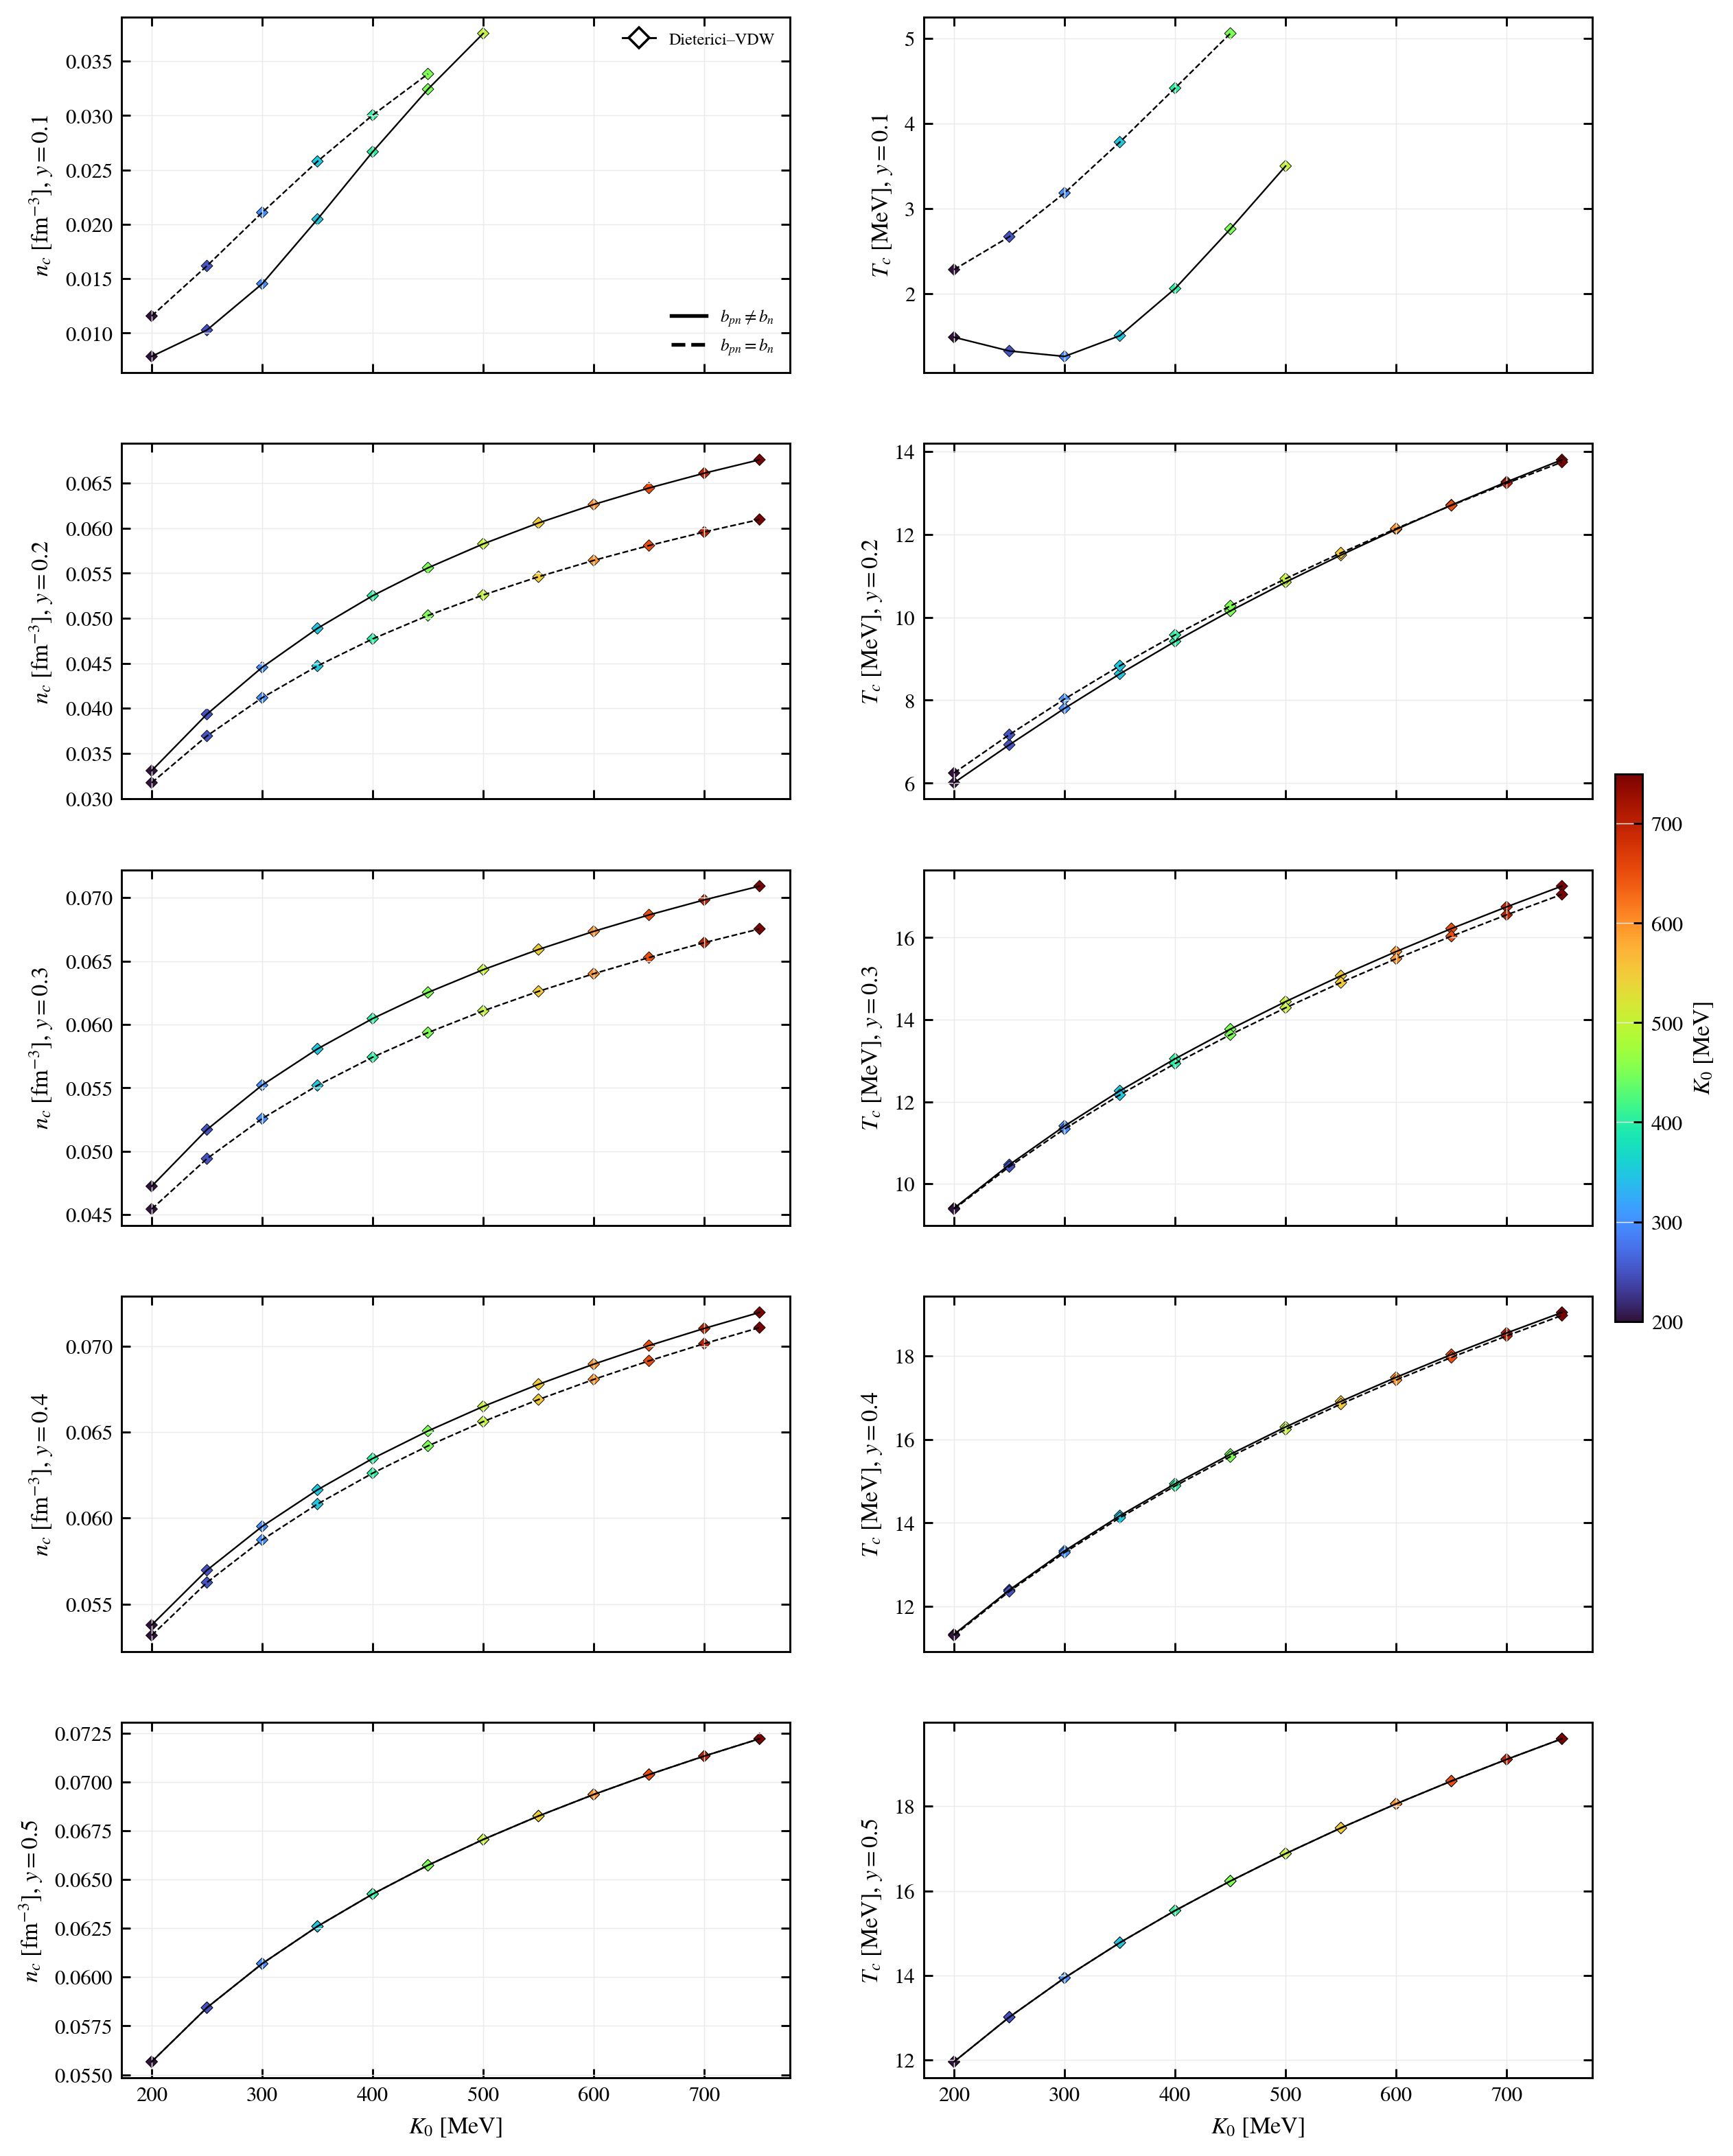

Beta products: 24/24
Critical rows: 120; successful: 109
TOV rows: 24/24
Results table: /home/dajuarez4/QMM/Paper/dieterici_vdw_Lambda300_K0_200_750_step50/tables/dieterici_vdw_lambda300_all_parameters_and_results.csv
Figures: /home/dajuarez4/QMM/Paper/dieterici_vdw_Lambda300_K0_200_750_step50/figures


In [8]:
figure_names = [
    'figure_dieterici_vdw_beta_binding_sound.png',
    'figure_dieterici_vdw_beta_composition.png',
    'figure_dieterici_vdw_eos_mass_radius.png',
    'figure_dieterici_vdw_observables.png',
    'figure_dieterici_vdw_fitted_parameters.png',
    'figure_dieterici_vdw_fixed_y_critical.png',
]
for name in figure_names:
    path = FIGURES / name
    if path.exists(): display(Image(filename=str(path)))
    else: print('Missing:', path)

print(f'Beta products: {len(available_beta)}/{N_CONFIGS}')
print(f'Critical rows: {len(critical_df)}; successful: {int((critical_df.status == "ok").sum()) if len(critical_df) else 0}')
print(f'TOV rows: {int(results.maximum_mass_msun.notna().sum())}/{len(results)}')
print('Results table:', RESULTS_CSV)
print('Figures:', FIGURES)